# Import library

In [1]:
import time
import os
import dagshub
import mlflow
import torch
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO, settings

# Global setting

In [2]:
# ML Flow dan DagsHub Integration
dagshub.init(repo_owner='abiyamf', repo_name='thesis', mlflow=True)
settings.update({"mlflow": True})
%matplotlib inline

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/thesis"

Repository abiyamf/thesis initialized!

In [3]:
os.environ["MLFLOW_KEEP_RUN_ACTIVE"] = "True"
gpu_name = torch.cuda.get_device_name(0)

def format_duration(seconds: float) -> str:
    """Convert seconds into 'Hh Mm Ss' format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours}h {minutes}m {secs}s"

def save_class_metrics(val_results, mode):
    # Ambil nama class
    names = val_results.names

    # Data per-class
    data = {
        "class": [names[i] for i in range(len(names))],
        "precision": val_results.box.p.tolist(),
        "recall": val_results.box.r.tolist(),
        "mAP50": val_results.box.ap50.tolist(),
        "mAP50-95": val_results.box.maps.tolist(),
    }

    # Tambahkan baris agregat "all"
    all_row = {
        "class": "all",
        "precision": float(val_results.box.mp),
        "recall": float(val_results.box.mr),
        "mAP50": float(val_results.box.map50),
        "mAP50-95": float(val_results.box.map),
    }

    for key in data.keys():
        data[key].insert(0, all_row[key])

    # Buat DataFrame dan simpan
    df = pd.DataFrame(data)
    csv_path = os.path.join(str(val_results.save_dir), f"class_metrics_{mode}.csv")
    df.to_csv(csv_path, index=False)

    return csv_path

# Yolo v12 - Base class (healthy)

In [4]:
# Variabel Global
projectType = "yolo12_object_detection_healthy_base_class_experiment"
imgsz = 640
models = ['yolo12n.pt','yolo12s.pt','yolo12m.pt']
sizes = ['nano','small','medium']
epochs = 100
batch = 16
data_path_objectDetection_all_class = "../../dataset_collection/roboflow/object_detection/object_detection_healthy"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_healthy_base_class"

In [5]:
mlflow.set_experiment(f"thesis-{projectType}")
for model_name, size in zip(models, sizes):
    time_now = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
    model = YOLO(model_name)

    with mlflow.start_run(run_name=f"{time_now}"):

        # Log global parameters
        mlflow.log_params({
            "project type": projectType,
            "gpu": gpu_name,
            "epochs": epochs,
            "batch": batch,
            "imgsz": imgsz,
        })

        # Train the model
        start_time = time.time()
        training = model.train(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            epochs=epochs, 
            imgsz=imgsz, 
            batch=batch, 
            project=f"{project_base_objectDetection_all_class}/training", 
            name=f"{size}",
            exist_ok=True,
            pretrained=False
        )
        end_time = time.time()

        # Validate the model
        validation = model.val(
            data=f"{data_path_objectDetection_all_class}/data.yaml", 
            imgsz=imgsz,
            project=f"{project_base_objectDetection_all_class}/validation",
            name=f"{size}",
            exist_ok=True,
            split="test"
        )

        csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{size}-validation-metrics.csv"
        os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
        with open(csv_filename, "w") as f:
            f.write(validation.to_csv())

        # Run validation + log class metrics
        mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
        mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

        # Log training time
        mlflow.log_params({
            "training time": format_duration(end_time - start_time),
        })

        mlflow.log_metrics({
            "val mAP50": float(validation.box.map50),
            "val mAP50-95": float(validation.box.map),
        })

        print(f"Finished training and validating {size} model.")

mlflow.end_run()

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../dataset_collection/roboflow/object_detection/object_detection_healthy/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentu

# Yolo v12 - Novel class

## Scheme 1

### Healthy -> Rust (Scheme-1A)

In [6]:
# Variabel Global
projectType = "yolo12_object_detection_novel_class_scheme-1A_experiment"
imgsz = 640
base_class_path = "runs/detect/results/yolo_v12/object_detection_healthy_base_class/training"
models = [f'{base_class_path}/nano/weights/best.pt',f'{base_class_path}/small/weights/best.pt',f'{base_class_path}/medium/weights/best.pt']
sizes = ['nano','small','medium']
epochs = 50
batch = 16
data_path_objectDetection_all_class = "../../dataset_collection/roboflow/k-shot/object_detection_healthy_rust"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_novel_class_scheme-1A"

In [7]:
mlflow.set_experiment(f"thesis-{projectType}")
for k in range(5,51,5):
    for model_name, size in zip(models, sizes):
        time_now = datetime.datetime.now().strftime("%m-%d_%H:%M:%S")
        model = YOLO(model_name)

        with mlflow.start_run(run_name=f"{size} {k}-shot 1A {time_now}"):

            # Log global parameters
            mlflow.log_params({
                "project type": projectType,
                "k-shot": k,
                "gpu": gpu_name,
                "epochs": epochs,
                "batch": batch,
                "imgsz": imgsz,
            })

            # Train the model
            start_time = time.time()
            training = model.train(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                epochs=epochs, 
                imgsz=imgsz, 
                batch=batch, 
                project=f"{project_base_objectDetection_all_class}/training/{k}-shot", 
                name=f"{size}",
                exist_ok=True
            )
            end_time = time.time()

            # Validate the model
            validation = model.val(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                imgsz=imgsz,
                project=f"{project_base_objectDetection_all_class}/validation/{k}-shot",
                name=f"{size}",
                exist_ok=True,
                split="test"
            )

            csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{k}-shot/{size}-validation-metrics.csv"
            os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
            with open(csv_filename, "w") as f:
                f.write(validation.to_csv())

            # Run validation + log class metrics
            mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
            mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

            # Log training time
            mlflow.log_params({
                "training time": format_duration(end_time - start_time),
            })

            mlflow.log_metrics({
                "val mAP50": float(validation.box.map50),
                "val mAP50-95": float(validation.box.map),
            })

            print(f"Finished training and validating {size} model.")

    mlflow.end_run()

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../dataset_collection/roboflow/k-shot/object_detection_healthy_rust/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/results/yol

### Healthy Rust -> Frog-eye-leaf-spot (Scheme 1 B)

In [8]:
# Variabel Global
projectType = "yolo12_object_detection_novel_class_scheme-1B_experiment"
imgsz = 640
base_class_path = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1A/training"
models = [f'{base_class_path}/50-shot/nano/weights/best.pt',f'{base_class_path}/50-shot/small/weights/best.pt',f'{base_class_path}/40-shot/medium/weights/best.pt']
sizes = ['nano','small','medium']
epochs = 50
batch = 16
data_path_objectDetection_all_class = "../../dataset_collection/roboflow/k-shot/object_detection_all_class"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_novel_class_scheme-1B"

In [9]:
mlflow.set_experiment(f"thesis-{projectType}")
for k in range(5,51,5):
    for model_name, size in zip(models, sizes):
        time_now = datetime.datetime.now().strftime("%m-%d_%H:%M:%S")
        model = YOLO(model_name)

        with mlflow.start_run(run_name=f"{size} {k}-shot 1B {time_now}"):

            # Log global parameters
            mlflow.log_params({
                "project type": projectType,
                "k-shot": k,
                "gpu": gpu_name,
                "epochs": epochs,
                "batch": batch,
                "imgsz": imgsz,
            })

            # Train the model
            start_time = time.time()
            training = model.train(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                epochs=epochs, 
                imgsz=imgsz, 
                batch=batch, 
                project=f"{project_base_objectDetection_all_class}/training/{k}-shot", 
                name=f"{size}",
                exist_ok=True
            )
            end_time = time.time()

            # Validate the model
            validation = model.val(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                imgsz=imgsz,
                project=f"{project_base_objectDetection_all_class}/validation/{k}-shot",
                name=f"{size}",
                exist_ok=True,
                split="test"
            )

            csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{k}-shot/{size}-validation-metrics.csv"
            os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
            with open(csv_filename, "w") as f:
                f.write(validation.to_csv())

            # Run validation + log class metrics
            mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
            mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

            # Log training time
            mlflow.log_params({
                "training time": format_duration(end_time - start_time),
            })

            mlflow.log_metrics({
                "val mAP50": float(validation.box.map50),
                "val mAP50-95": float(validation.box.map),
            })

            print(f"Finished training and validating {size} model.")

    mlflow.end_run()

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../dataset_collection/roboflow/k-shot/object_detection_all_class/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/results/yolo_v

### Comparison

Loading data for Scheme 1A...
Loading data for Scheme 1B...


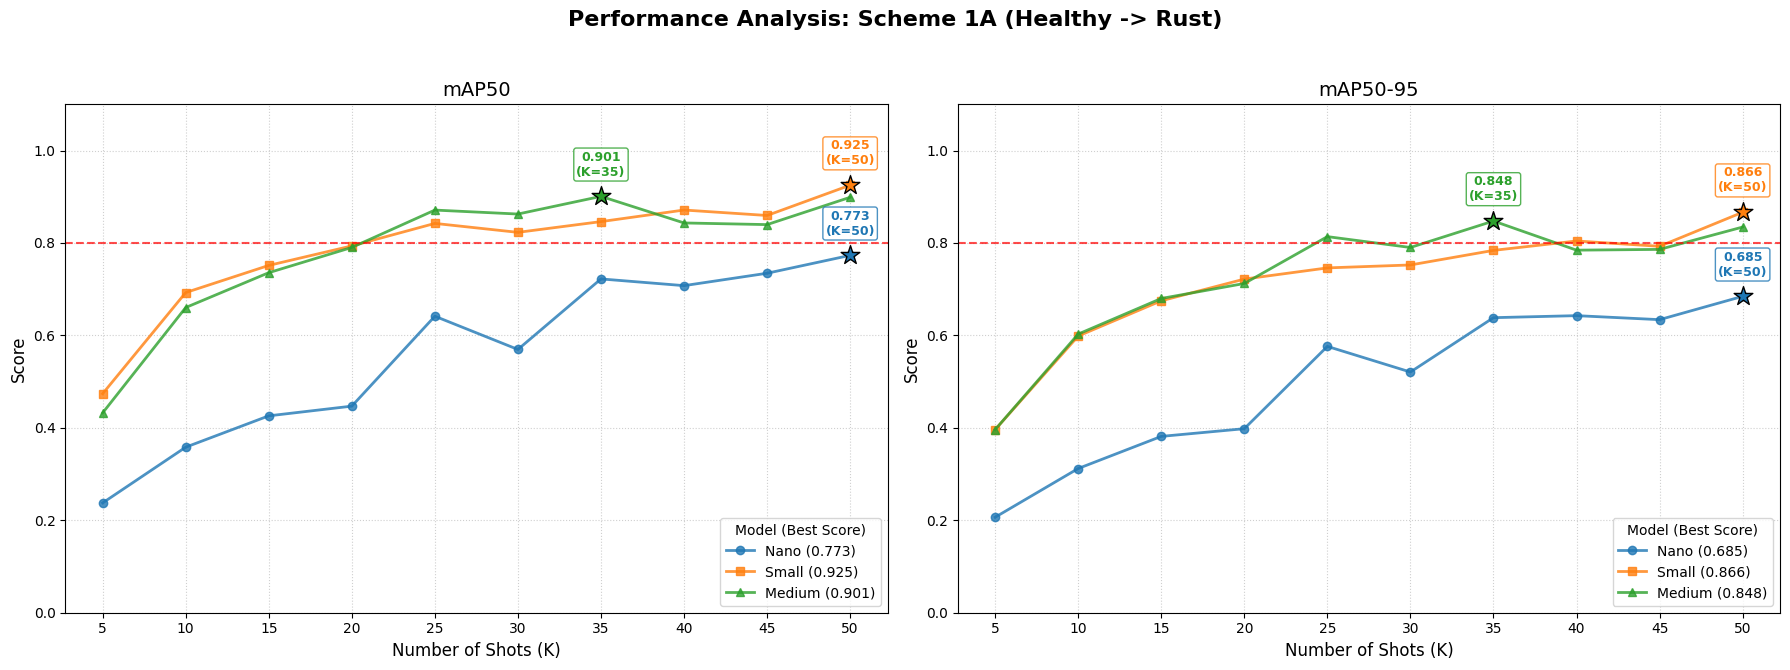

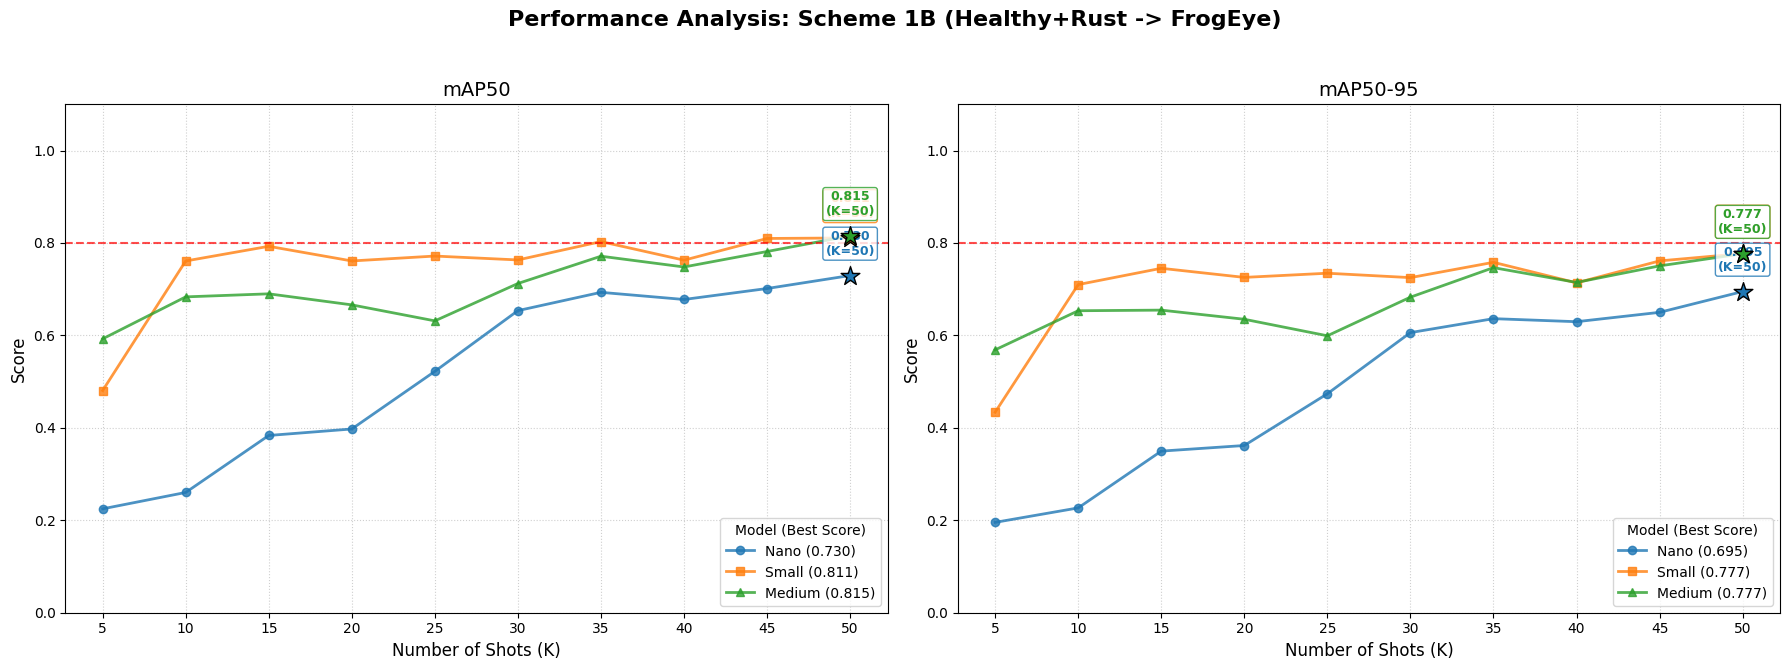

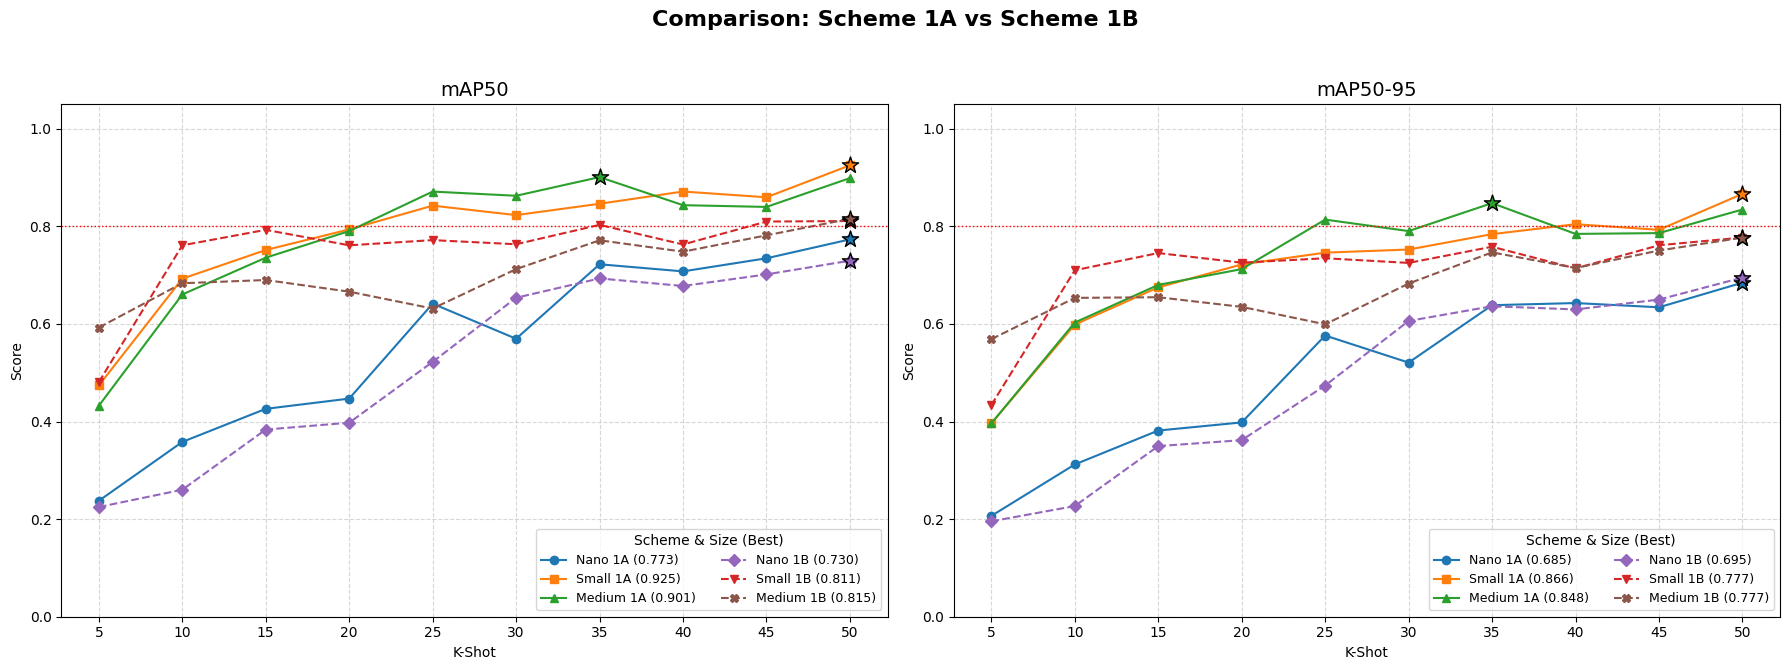

In [4]:
# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# Path Root Project (Sesuaikan dengan path lokal Anda)
BASE_PATH_SCHEME_1A = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1A"
BASE_PATH_SCHEME_1B = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"

# --- STYLE CONFIGURATION ---

# 1. Style untuk Plot Individual (Scheme Analysis)
INDIVIDUAL_STYLE = {
    'nano':   {'color': '#1f77b4', 'marker': 'o', 'label': 'Nano'},   # Biru
    'small':  {'color': '#ff7f0e', 'marker': 's', 'label': 'Small'},  # Oranye
    'medium': {'color': '#2ca02c', 'marker': '^', 'label': 'Medium'}  # Hijau
}

# 2. Style Khusus Comparison (6 Warna & Marker Berbeda)
# Agar Nano 1A dan Nano 1B beda warna & beda icon
COMPARE_STYLE = {
    # Scheme 1A (Solid Colors)
    '1A_nano':   {'color': '#1f77b4', 'marker': 'o', 'line': '-', 'label': 'Nano 1A'},   # Biru / Bulat
    '1A_small':  {'color': '#ff7f0e', 'marker': 's', 'line': '-', 'label': 'Small 1A'},   # Oranye / Kotak
    '1A_medium': {'color': '#2ca02c', 'marker': '^', 'line': '-', 'label': 'Medium 1A'},  # Hijau / Segitiga Atas

    # Scheme 1B (Distinct Colors & Markers)
    '1B_nano':   {'color': '#9467bd', 'marker': 'D', 'line': '--', 'label': 'Nano 1B'},  # Ungu / Diamond
    '1B_small':  {'color': '#d62728', 'marker': 'v', 'line': '--', 'label': 'Small 1B'},  # Merah / Segitiga Bawah
    '1B_medium': {'color': '#8c564b', 'marker': 'X', 'line': '--', 'label': 'Medium 1B'}   # Coklat / Silang
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_name):
    data = []
    print(f"Loading data for {scheme_name}...")
    
    for k in K_VALUES:
        for size in SIZES:
            # Path ke results.csv dalam folder training
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns] # Bersihkan spasi nama kolom
                    
                    if df.empty: continue

                    last_row = df.iloc[-1]
                    
                    # Ambil metrics (Handle nama kolom ultralytics)
                    map50 = last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0))
                    map50_95 = last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))

                    data.append({
                        'Scheme': scheme_name,
                        'K': k,
                        'Size': size,
                        'mAP50': map50,
                        'mAP50-95': map50_95
                    })
                except Exception as e:
                    # print(f"Error reading {csv_path}: {e}")
                    pass
                
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING INDIVIDUAL (DENGAN ANOTASI TEKS) ---
def plot_scheme_performance(df, scheme_name):
    if df.empty:
        print(f"Data kosong untuk {scheme_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Performance Analysis: {scheme_name}", fontsize=16, fontweight='bold')
    
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    for idx, (metric_col, title) in enumerate(metrics):
        ax = axes[idx]
        
        for size in SIZES:
            subset = df[df['Size'] == size].sort_values('K')
            if subset.empty: continue
            
            style = INDIVIDUAL_STYLE[size]
            
            # Cari Nilai Terbaik
            max_val = subset[metric_col].max()
            max_k = subset.loc[subset[metric_col].idxmax(), 'K']
            
            legend_label = f"{style['label']} ({max_val:.3f})"
            
            # 1. Plot Garis
            ax.plot(subset['K'], subset[metric_col], 
                    marker=style['marker'], color=style['color'], label=legend_label, 
                    linewidth=2, markersize=6, alpha=0.8)
            
            # 2. Plot Bintang (Star) di Puncak
            ax.scatter(max_k, max_val, s=200, color=style['color'], edgecolors='black', zorder=10, marker='*')
            
            # 3. KEMBALIKAN ANOTASI TEKS DI ATAS BINTANG
            ax.annotate(f"{max_val:.3f}\n(K={max_k})", 
                        (max_k, max_val), 
                        xytext=(0, 15), textcoords='offset points', 
                        ha='center', fontsize=9, fontweight='bold', color=style['color'],
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=style['color'], alpha=0.8))

        # Threshold Line
        ax.axhline(y=THRESHOLD_VAL, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Number of Shots (K)", fontsize=12)
        ax.set_ylabel("Score", fontsize=12)
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.1) # Sedikit dilebihkan agar teks anotasi tidak terpotong
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='lower right', title="Model (Best Score)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 4. FUNGSI PLOTTING PERBANDINGAN (6 WARNA BEDA + STAR) ---
def plot_comparison(df1, df2):
    if df1.empty or df2.empty: return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("Comparison: Scheme 1A vs Scheme 1B", fontsize=16, fontweight='bold')
    
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    for idx, (metric_col, title) in enumerate(metrics):
        ax = axes[idx]
        
        # --- LOOP UNTUK SCHEME 1A ---
        for size in SIZES:
            subset = df1[df1['Size'] == size].sort_values('K')
            if subset.empty: continue
            
            # Ambil Style Khusus "1A_nano", "1A_small", dll
            key = f"1A_{size}"
            style = COMPARE_STYLE[key]
            
            max_val = subset[metric_col].max()
            max_k = subset.loc[subset[metric_col].idxmax(), 'K']

            # Plot Garis
            ax.plot(subset['K'], subset[metric_col], 
                    color=style['color'], marker=style['marker'], linestyle=style['line'], 
                    label=f"{style['label']} ({max_val:.3f})")
            
            # Plot Bintang (Star) Scheme 1A
            ax.scatter(max_k, max_val, s=150, color=style['color'], edgecolors='black', zorder=10, marker='*')

        # --- LOOP UNTUK SCHEME 1B ---
        for size in SIZES:
            subset = df2[df2['Size'] == size].sort_values('K')
            if subset.empty: continue
            
            # Ambil Style Khusus "1B_nano", "1B_small", dll
            key = f"1B_{size}"
            style = COMPARE_STYLE[key]
            
            max_val = subset[metric_col].max()
            max_k = subset.loc[subset[metric_col].idxmax(), 'K']

            # Plot Garis
            ax.plot(subset['K'], subset[metric_col], 
                    color=style['color'], marker=style['marker'], linestyle=style['line'], 
                    label=f"{style['label']} ({max_val:.3f})")
            
            # Plot Bintang (Star) Scheme 1B
            ax.scatter(max_k, max_val, s=150, color=style['color'], edgecolors='black', zorder=10, marker='*')

        # Threshold Line
        ax.axhline(y=THRESHOLD_VAL, color='red', linestyle=':', linewidth=1)
        
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("K-Shot")
        ax.set_ylabel("Score")
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Legend (Sekarang ada 6 item)
        ax.legend(title="Scheme & Size (Best)", fontsize=9, loc='lower right', ncol=2)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 5. EKSEKUSI ---
df_1a = load_metrics_from_csv(BASE_PATH_SCHEME_1A, "Scheme 1A")
df_1b = load_metrics_from_csv(BASE_PATH_SCHEME_1B, "Scheme 1B")

# Plot Individual (Anotasi Teks Kembali)
plot_scheme_performance(df_1a, "Scheme 1A (Healthy -> Rust)")
plot_scheme_performance(df_1b, "Scheme 1B (Healthy+Rust -> FrogEye)")
# Plot Comparison (Beda Warna Semua + Bintang)
plot_comparison(df_1a, df_1b)

## Scheme 2

In [7]:
# Variabel Global
projectType = "yolo12_object_detection_novel_class_scheme-2_experiment"
imgsz = 640
base_class_path = "runs/detect/results/yolo_v12/object_detection_healthy_base_class/training"
models = [f'{base_class_path}/nano/weights/best.pt',f'{base_class_path}/small/weights/best.pt',f'{base_class_path}/medium/weights/best.pt']
sizes = ['nano','small','medium']
epochs = 50
batch = 16
data_path_objectDetection_all_class = "../../dataset_collection/roboflow/k-shot/object_detection_all_class"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_novel_class_scheme-2"

In [8]:
mlflow.set_experiment(f"thesis-{projectType}")
for k in range(5,51,5):
    for model_name, size in zip(models, sizes):
        time_now = datetime.datetime.now().strftime("%m-%d_%H:%M:%S")
        model = YOLO(model_name)

        with mlflow.start_run(run_name=f"{size} {k}-shot 2 {time_now}"):

            # Log global parameters
            mlflow.log_params({
                "project type": projectType,
                "k-shot": k,
                "gpu": gpu_name,
                "epochs": epochs,
                "batch": batch,
                "imgsz": imgsz,
            })

            # Train the model
            start_time = time.time()
            training = model.train(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                epochs=epochs, 
                imgsz=imgsz, 
                batch=batch, 
                project=f"{project_base_objectDetection_all_class}/training/{k}-shot", 
                name=f"{size}",
                exist_ok=True,
            )
            end_time = time.time()

            # Validate the model
            validation = model.val(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                imgsz=imgsz,
                project=f"{project_base_objectDetection_all_class}/validation/{k}-shot",
                name=f"{size}",
                exist_ok=True,
                split="test"
            )

            csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{k}-shot/{size}-validation-metrics.csv"
            os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
            with open(csv_filename, "w") as f:
                f.write(validation.to_csv())

            # Run validation + log class metrics
            mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
            mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

            # Log training time
            mlflow.log_params({
                "training time": format_duration(end_time - start_time),
            })

            mlflow.log_metrics({
                "val mAP50": float(validation.box.map50),
                "val mAP50-95": float(validation.box.map),
            })

            print(f"Finished training and validating {size} model.")

    mlflow.end_run()

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../dataset_collection/roboflow/k-shot/object_detection_all_class/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/results/yolo_v

### Comparison

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) # 5, 10, ..., 50
THRESHOLD_VAL = 0.8        # Garis batas target

# Path Root Project Scheme 2 (Sesuai kode training Anda)
# Pastikan path ini benar relatif terhadap lokasi script/notebook Anda
BASE_PATH_SCHEME_2 = "results/yolo_v12/object_detection_novel_class_scheme-2"

# Konfigurasi Visual (Warna & Marker Konsisten)
STYLE_CONFIG = {
    'nano':   {'color': '#1f77b4', 'marker': 'o', 'label': 'Nano'},   # Biru
    'small':  {'color': '#ff7f0e', 'marker': 's', 'label': 'Small'},  # Oranye
    'medium': {'color': '#2ca02c', 'marker': '^', 'label': 'Medium'}  # Hijau
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_name):
    data = []
    print(f"Loading data for {scheme_name}...")
    
    for k in K_VALUES:
        for size in SIZES:
            # Mengambil data dari folder TRAINING sesuai instruksi style sebelumnya
            # Path: .../training/{k}-shot/{size}/results.csv
            csv_path = os.path.join(
                base_project_path, 
                "training", 
                f"{k}-shot", 
                size, 
                "results.csv"
            )
            
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    # Bersihkan nama kolom (trim spasi)
                    df.columns = [c.strip() for c in df.columns]
                    
                    if df.empty: 
                        print(f"  [Warning] File kosong: {csv_path}")
                        continue

                    # Ambil baris terakhir (Final Epoch)
                    last_row = df.iloc[-1]
                    
                    # Ambil metric mAP (Handle variasi nama kolom Ultralytics)
                    map50 = last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0))
                    map50_95 = last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))

                    data.append({
                        'Scheme': scheme_name,
                        'K': k,
                        'Size': size,
                        'mAP50': map50,
                        'mAP50-95': map50_95
                    })
                except Exception as e:
                    # print(f"  [Error] Gagal membaca {csv_path}: {e}")
                    pass
            else:
                # print(f"  [Missing] {csv_path}")
                pass
                
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING (STYLE LENGKAP) ---
def plot_scheme_performance(df, scheme_name):
    if df.empty:
        print(f"Data kosong untuk {scheme_name}, tidak ada yang di-plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Performance Analysis: {scheme_name} (K-Shot Optimization)", fontsize=16, fontweight='bold')
    
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    for idx, (metric_col, title) in enumerate(metrics):
        ax = axes[idx]
        
        for size in SIZES:
            subset = df[df['Size'] == size].sort_values('K')
            if subset.empty: continue
            
            style = STYLE_CONFIG[size]
            
            # Cari Nilai Terbaik (Peak)
            max_val = subset[metric_col].max()
            max_k = subset.loc[subset[metric_col].idxmax(), 'K']
            
            legend_label = f"{style['label']} ({max_val:.3f})"
            
            # 1. Plot Garis Utama
            ax.plot(subset['K'], subset[metric_col], 
                    marker=style['marker'], color=style['color'], label=legend_label, 
                    linewidth=2, markersize=6, alpha=0.8)
            
            # 2. Plot Bintang (Star) di Puncak
            ax.scatter(max_k, max_val, s=200, color=style['color'], edgecolors='black', zorder=10, marker='*')
            
            # 3. Anotasi Teks (Nilai & K)
            ax.annotate(f"{max_val:.3f}\n(K={max_k})", 
                        (max_k, max_val), 
                        xytext=(0, 15), textcoords='offset points', 
                        ha='center', fontsize=9, fontweight='bold', color=style['color'],
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=style['color'], alpha=0.8))

        # Garis Threshold
        ax.axhline(y=THRESHOLD_VAL, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(min(K_VALUES), THRESHOLD_VAL + 0.01, f'Threshold ({THRESHOLD_VAL})', 
                color='red', fontsize=10, style='italic', va='bottom')

        # Kosmetik Grafik
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Number of Shots (K)", fontsize=12)
        ax.set_ylabel("Score", fontsize=12)
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.1) # Memberi ruang untuk anotasi di atas
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Legend (Menampilkan size dan nilai terbaiknya)
        ax.legend(loc='lower right', title="Model (Best Score)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 4. EKSEKUSI ---
# Load Data Scheme 2
df_scheme2 = load_metrics_from_csv(BASE_PATH_SCHEME_2, "Scheme 2")

# Tampilkan Grafik
plot_scheme_performance(df_scheme2, "Scheme 2 (Base -> All Classes)")

Loading data for Scheme 2...
Data kosong untuk Scheme 2 (Base -> All Classes), tidak ada yang di-plot.


## Scheme 3

In [10]:
# Variabel Global
projectType = "yolo12_object_detection_novel_class_scheme-3_experiment"
imgsz = 640
models = ["yolo12n.pt","yolo12s.pt","yolo12m.pt"]
sizes = ['nano','small','medium']
epochs = 50
batch = 16
data_path_objectDetection_all_class = "../../dataset_collection/roboflow/k-shot/object_detection_all_class"
project_base_objectDetection_all_class = "results/yolo_v12/object_detection_novel_class_scheme-3"

In [11]:
mlflow.set_experiment(f"thesis-{projectType}")
for k in range(5,51,5):
    for model_name, size in zip(models, sizes):
        time_now = datetime.datetime.now().strftime("%m-%d_%H:%M:%S")
        model = YOLO(model_name)

        with mlflow.start_run(run_name=f"{size} {k}-shot 3 {time_now}"):

            # Log global parameters
            mlflow.log_params({
                "project type": projectType,
                "k-shot": k,
                "gpu": gpu_name,
                "epochs": epochs,
                "batch": batch,
                "imgsz": imgsz,
            })

            # Train the model
            start_time = time.time()
            num_freeze = int(len(model.model.model) * 0.90)
            training = model.train(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                epochs=epochs, 
                imgsz=imgsz, 
                batch=batch, 
                project=f"{project_base_objectDetection_all_class}/training/{k}-shot", 
                name=f"{size}",
                exist_ok=True,
                pretrained=False
            )
            end_time = time.time()

            # Validate the model
            validation = model.val(
                data=f"{data_path_objectDetection_all_class}/{k}-shot.yaml", 
                imgsz=imgsz,
                project=f"{project_base_objectDetection_all_class}/validation/{k}-shot",
                name=f"{size}",
                exist_ok=True,
                split="test"
            )

            csv_filename = f"{project_base_objectDetection_all_class}/validation/summary/{k}-shot/{size}-validation-metrics.csv"
            os.makedirs(os.path.dirname(csv_filename), exist_ok=True)
            with open(csv_filename, "w") as f:
                f.write(validation.to_csv())

            # Run validation + log class metrics
            mlflow.log_artifact(save_class_metrics(training, "training"), artifact_path="class_metrics")
            mlflow.log_artifact(save_class_metrics(validation, "validation"), artifact_path="class_metrics")

            # Log training time
            mlflow.log_params({
                "training time": format_duration(end_time - start_time),
            })

            mlflow.log_metrics({
                "val mAP50": float(validation.box.map50),
                "val mAP50-95": float(validation.box.map),
            })

            print(f"Finished training and validating {size} model.")

    mlflow.end_run()

New https://pypi.org/project/ultralytics/8.4.84 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../dataset_collection/roboflow/k-shot/object_detection_all_class/5-shot.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937

### Comparison

Loading data for Scheme 3...


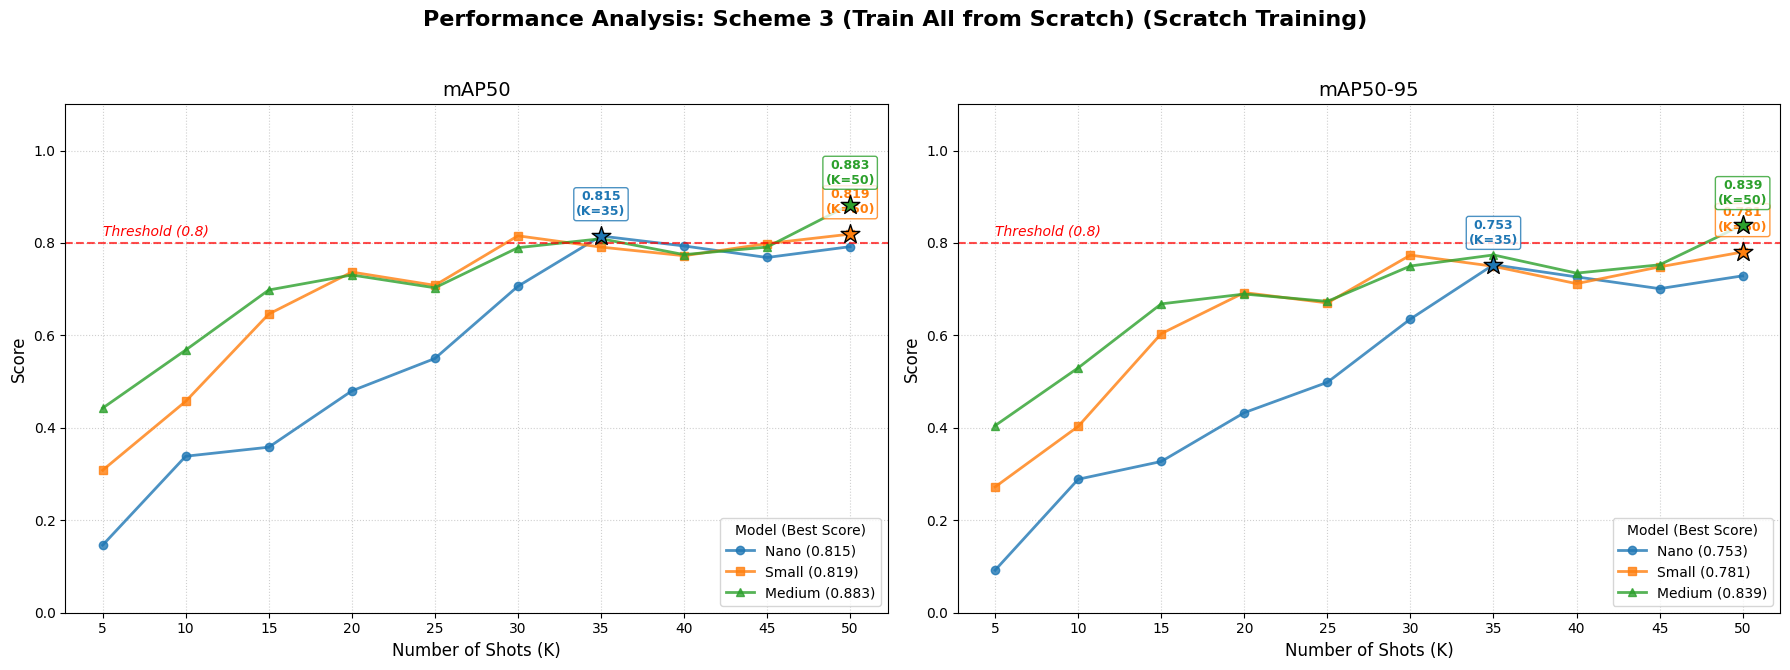

In [12]:
# Comparison mencari K-Shot terbaik dari skema 3
# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) # 5, 10, ..., 50
THRESHOLD_VAL = 0.8        # Garis batas target

# Path Root Project Scheme 3 (Sesuai kode training Anda)
# Pastikan path ini benar relatif terhadap lokasi script/notebook Anda
BASE_PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# Konfigurasi Visual (Warna & Marker Konsisten)
STYLE_CONFIG = {
    'nano':   {'color': '#1f77b4', 'marker': 'o', 'label': 'Nano'},   # Biru
    'small':  {'color': '#ff7f0e', 'marker': 's', 'label': 'Small'},  # Oranye
    'medium': {'color': '#2ca02c', 'marker': '^', 'label': 'Medium'}  # Hijau
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_name):
    data = []
    print(f"Loading data for {scheme_name}...")
    
    for k in K_VALUES:
        for size in SIZES:
            # Mengambil data dari folder TRAINING
            # Path: .../training/{k}-shot/{size}/results.csv
            csv_path = os.path.join(
                base_project_path, 
                "training", 
                f"{k}-shot", 
                size, 
                "results.csv"
            )
            
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    # Bersihkan nama kolom (trim spasi)
                    df.columns = [c.strip() for c in df.columns]
                    
                    if df.empty: 
                        print(f"  [Warning] File kosong: {csv_path}")
                        continue

                    # Ambil baris terakhir (Final Epoch)
                    last_row = df.iloc[-1]
                    
                    # Ambil metric mAP (Handle variasi nama kolom Ultralytics)
                    map50 = last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0))
                    map50_95 = last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))

                    data.append({
                        'Scheme': scheme_name,
                        'K': k,
                        'Size': size,
                        'mAP50': map50,
                        'mAP50-95': map50_95
                    })
                except Exception as e:
                    # print(f"  [Error] Gagal membaca {csv_path}: {e}")
                    pass
            else:
                # print(f"  [Missing] {csv_path}")
                pass
                
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING (STYLE LENGKAP) ---
def plot_scheme_performance(df, scheme_name):
    if df.empty:
        print(f"Data kosong untuk {scheme_name}, tidak ada yang di-plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Performance Analysis: {scheme_name} (Scratch Training)", fontsize=16, fontweight='bold')
    
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    for idx, (metric_col, title) in enumerate(metrics):
        ax = axes[idx]
        
        for size in SIZES:
            subset = df[df['Size'] == size].sort_values('K')
            if subset.empty: continue
            
            style = STYLE_CONFIG[size]
            
            # Cari Nilai Terbaik (Peak)
            max_val = subset[metric_col].max()
            max_k = subset.loc[subset[metric_col].idxmax(), 'K']
            
            legend_label = f"{style['label']} ({max_val:.3f})"
            
            # 1. Plot Garis Utama
            ax.plot(subset['K'], subset[metric_col], 
                    marker=style['marker'], color=style['color'], label=legend_label, 
                    linewidth=2, markersize=6, alpha=0.8)
            
            # 2. Plot Bintang (Star) di Puncak
            ax.scatter(max_k, max_val, s=200, color=style['color'], edgecolors='black', zorder=10, marker='*')
            
            # 3. Anotasi Teks (Nilai & K)
            ax.annotate(f"{max_val:.3f}\n(K={max_k})", 
                        (max_k, max_val), 
                        xytext=(0, 15), textcoords='offset points', 
                        ha='center', fontsize=9, fontweight='bold', color=style['color'],
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=style['color'], alpha=0.8))

        # Garis Threshold
        ax.axhline(y=THRESHOLD_VAL, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(min(K_VALUES), THRESHOLD_VAL + 0.01, f'Threshold ({THRESHOLD_VAL})', 
                color='red', fontsize=10, style='italic', va='bottom')

        # Kosmetik Grafik
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Number of Shots (K)", fontsize=12)
        ax.set_ylabel("Score", fontsize=12)
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.1) # Memberi ruang untuk anotasi di atas
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Legend (Menampilkan size dan nilai terbaiknya)
        ax.legend(loc='lower right', title="Model (Best Score)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 4. EKSEKUSI ---
# Load Data Scheme 3
df_scheme3 = load_metrics_from_csv(BASE_PATH_SCHEME_3, "Scheme 3")

# Tampilkan Grafik
plot_scheme_performance(df_scheme3, "Scheme 3 (Train All from Scratch)")

## Comparison Scheme 1,2,3

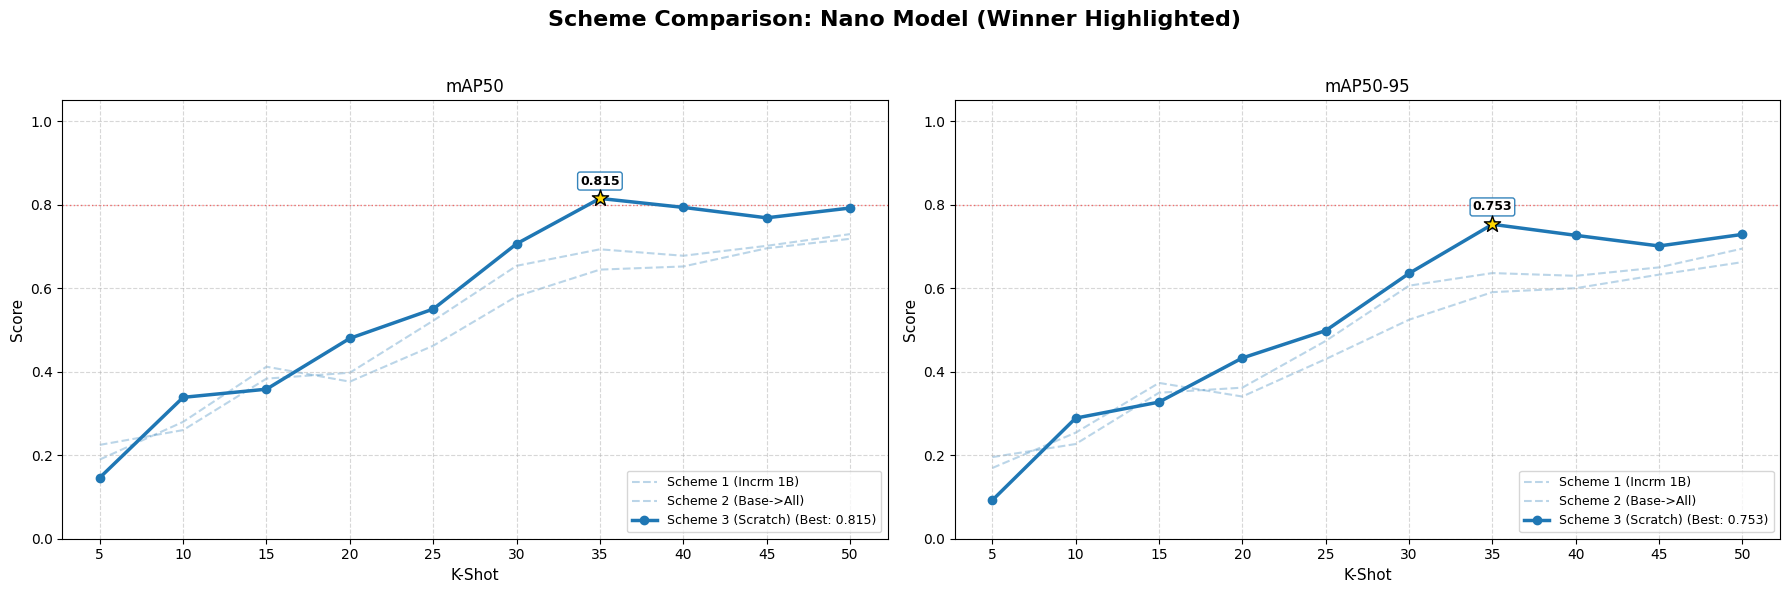

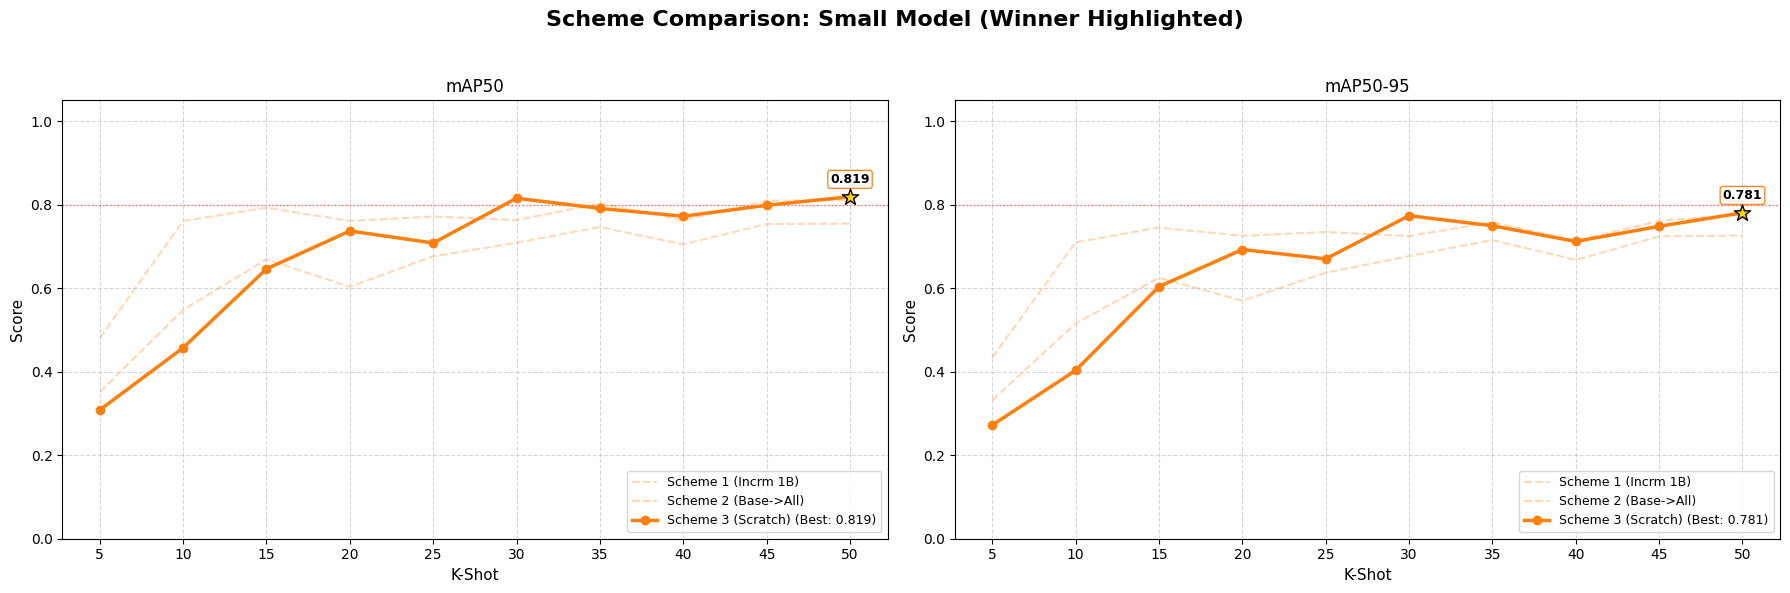

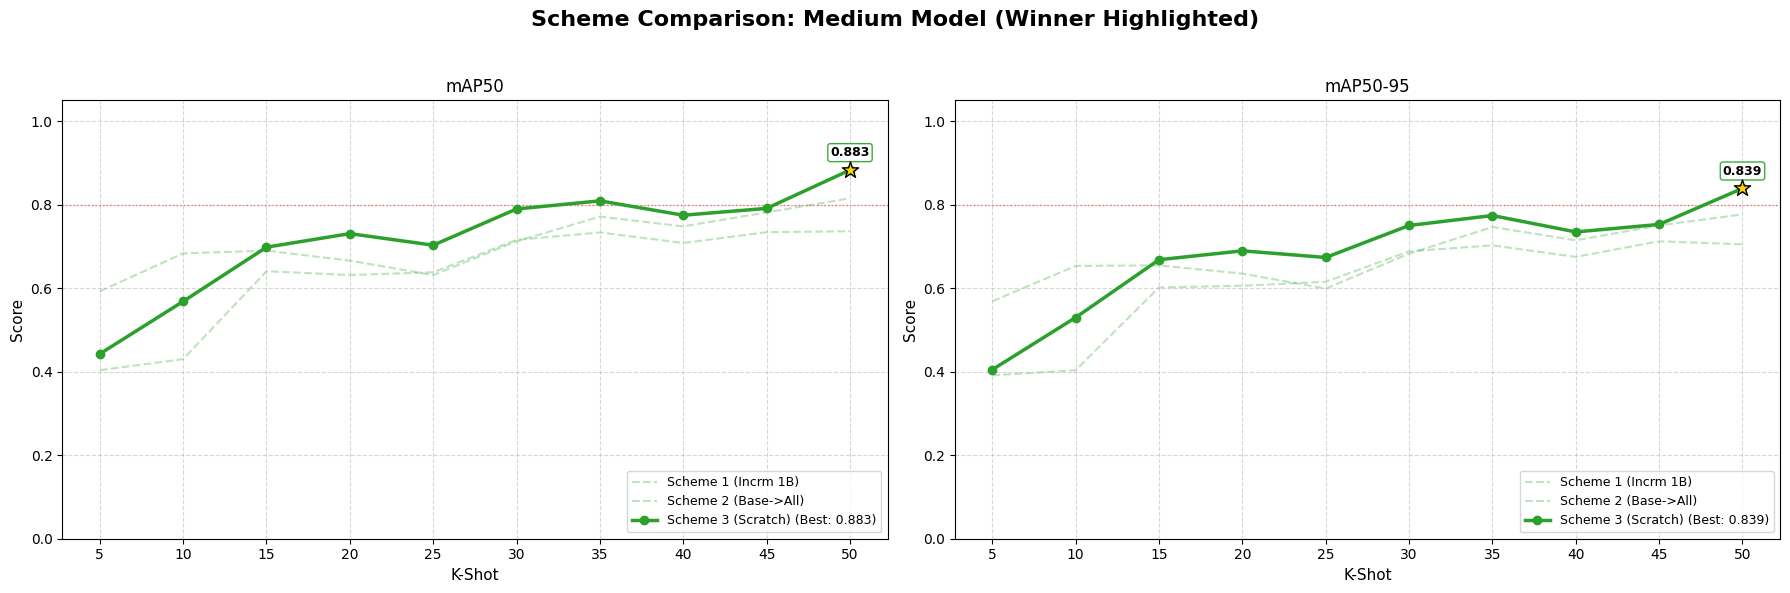

In [13]:
# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# --- PATH DATA ---
PATH_SCHEME_1 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"
PATH_SCHEME_2 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-2"
PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# Mapping Nama Scheme
SCHEMES_MAP = {
    'S1': {'path': PATH_SCHEME_1, 'label': 'Scheme 1 (Incrm 1B)'},
    'S2': {'path': PATH_SCHEME_2, 'label': 'Scheme 2 (Base->All)'},
    'S3': {'path': PATH_SCHEME_3, 'label': 'Scheme 3 (Scratch)'}
}

# Warna berdasarkan Size
SIZE_COLORS = {
    'nano': '#1f77b4',   # Biru
    'small': '#ff7f0e',  # Oranye
    'medium': '#2ca02c'  # Hijau
}

# --- 2. FUNGSI LOAD DATA (TIDAK BERUBAH) ---
def load_metrics_from_csv(base_project_path, scheme_code):
    data = []
    for k in K_VALUES:
        for size in SIZES:
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                    if df.empty: continue
                    last_row = df.iloc[-1]
                    data.append({
                        'Scheme': scheme_code,
                        'K': k,
                        'Size': size,
                        'mAP50': last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0)),
                        'mAP50-95': last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))
                    })
                except: pass
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING (MODIFIKASI: 1 SIZE = 1 FIGURE) ---
def plot_per_model_comparison(data_dict):
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    # LOOP UTAMA: Berdasarkan Size (Nano -> Small -> Medium)
    # Setiap iterasi loop ini membuat 1 Figure baru
    for size in SIZES:
        
        # Buat Figure Terpisah untuk setiap Size (1 Baris, 2 Kolom)
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f"Scheme Comparison: {size.capitalize()} Model (Winner Highlighted)", fontsize=16, fontweight='bold')
        
        color = SIZE_COLORS[size]
        
        # Loop per Metric (Subplot Kiri & Kanan)
        for col_idx, (metric_col, metric_title) in enumerate(metrics):
            ax = axes[col_idx]
            
            # --- LOGIKA CARI PEMENANG (Sama seperti sebelumnya) ---
            best_scheme = None
            max_peak_val = -1
            plot_data = [] 
            
            for scheme_code in ['S1', 'S2', 'S3']:
                df = data_dict[scheme_code]
                if df.empty: continue
                
                subset = df[df['Size'] == size].sort_values('K')
                if subset.empty: continue
                
                peak = subset[metric_col].max()
                if peak > max_peak_val:
                    max_peak_val = peak
                    best_scheme = scheme_code
                
                plot_data.append({'code': scheme_code, 'data': subset})
            
            # --- PLOTTING ---
            for item in plot_data:
                code = item['code']
                subset = item['data']
                
                is_winner = (code == best_scheme)
                label_name = SCHEMES_MAP[code]['label']
                
                # Style Logic (Sama persis)
                if is_winner:
                    alpha = 1.0
                    linewidth = 2.5
                    linestyle = '-' 
                    zorder = 10
                    marker = 'o'
                    label = f"{label_name} (Best: {subset[metric_col].max():.3f})"
                else:
                    alpha = 0.3 
                    linewidth = 1.5
                    linestyle = '--'
                    zorder = 1
                    marker = None 
                    label = f"{label_name}"

                # Plot Garis
                ax.plot(subset['K'], subset[metric_col], 
                        color=color, linestyle=linestyle, linewidth=linewidth, 
                        marker=marker, markersize=6, alpha=alpha, zorder=zorder,
                        label=label)
                
                # Plot Bintang (Hanya Winner)
                if is_winner:
                    max_k = subset.loc[subset[metric_col].idxmax(), 'K']
                    max_val = subset[metric_col].max()
                    
                    ax.scatter(max_k, max_val, s=150, color='gold', edgecolors='black', zorder=11, marker='*')
                    
                    # Anotasi
                    ax.annotate(f"{max_val:.3f}", (max_k, max_val), 
                                xytext=(0, 10), textcoords='offset points', 
                                ha='center', fontsize=9, fontweight='bold', color='black',
                                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9))

            # Threshold Line
            ax.axhline(y=THRESHOLD_VAL, color='red', linestyle=':', linewidth=1, alpha=0.5)
            
            # Kosmetik Subplot
            ax.set_title(f"{metric_title}", fontsize=12)
            ax.set_xlabel("K-Shot", fontsize=11)
            ax.set_ylabel("Score", fontsize=11)
            ax.set_xticks(K_VALUES)
            ax.set_ylim(0, 1.05)
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(loc='lower right', fontsize=9)

        plt.tight_layout(rect=[0, 0.0, 1, 0.95])
        plt.show() # Tampilkan 1 Figure selesai, lalu lanjut loop size berikutnya

# --- 4. EKSEKUSI ---
data_store = {}
for code, info in SCHEMES_MAP.items():
    data_store[code] = load_metrics_from_csv(info['path'], code)

# Plot
plot_per_model_comparison(data_store)

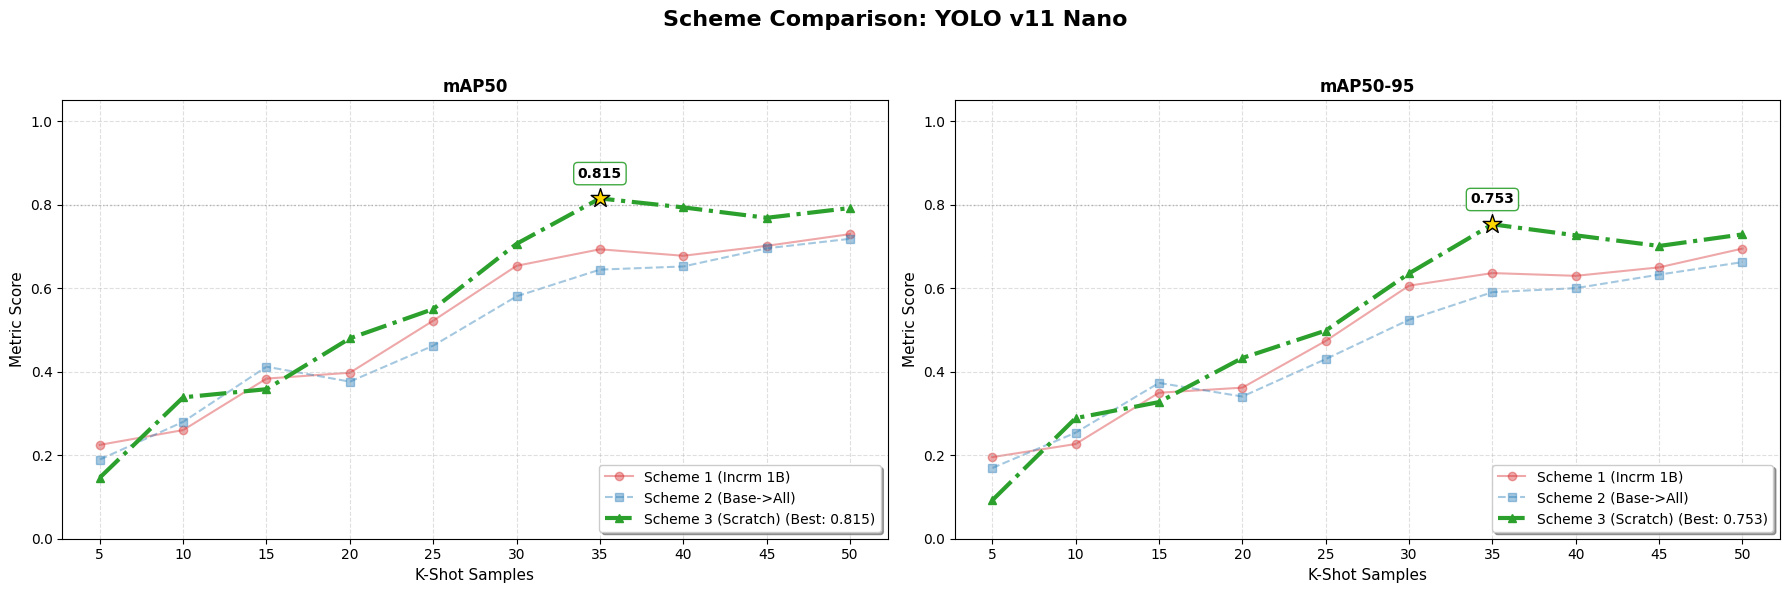

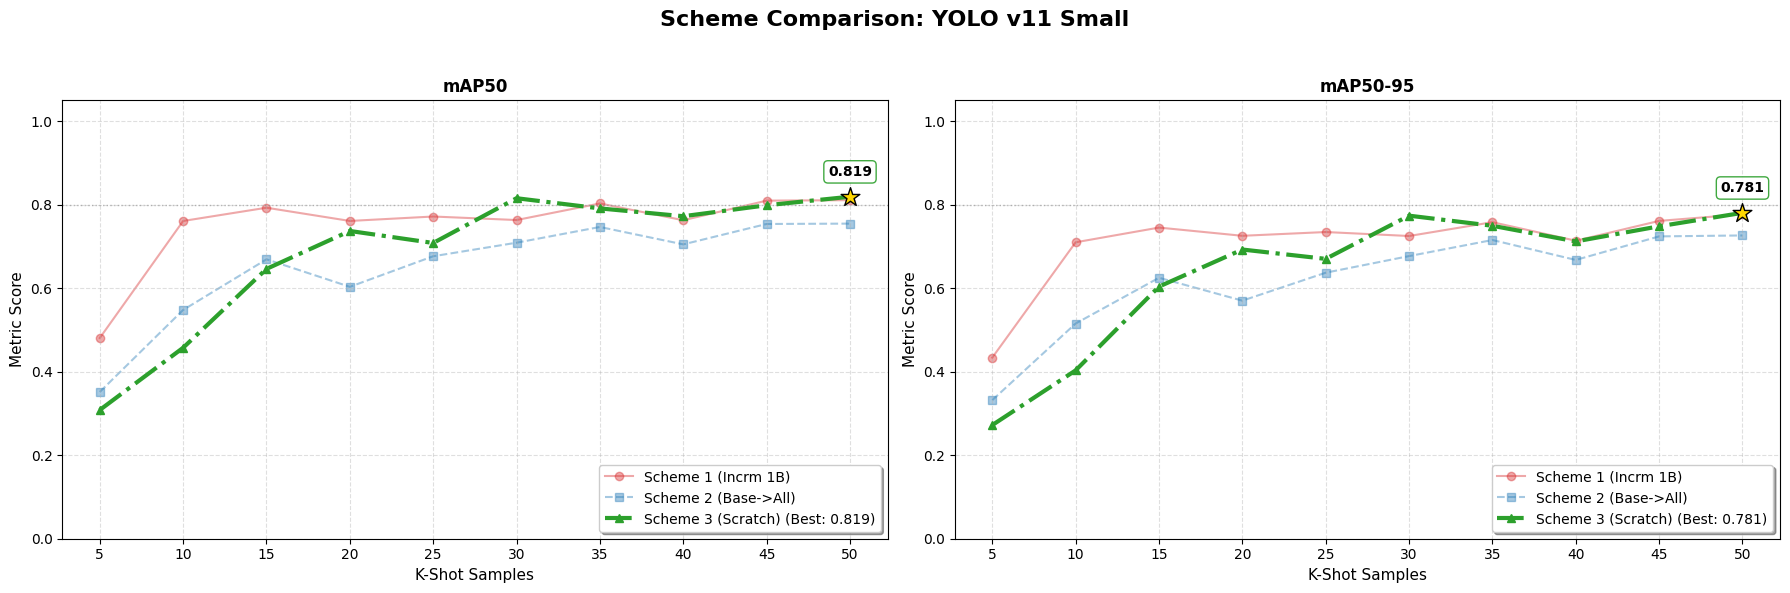

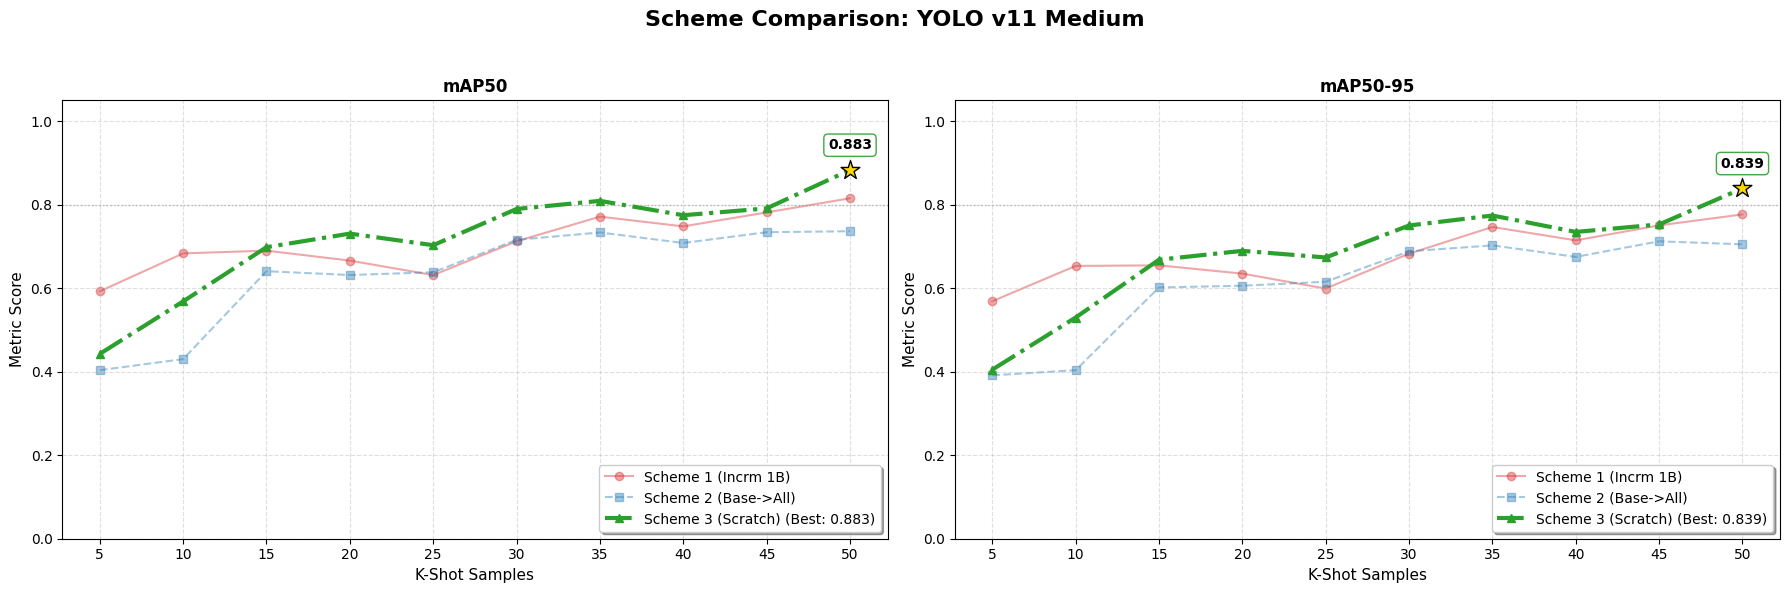

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# --- PATH DATA ---
PATH_SCHEME_1 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"
PATH_SCHEME_2 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-2"
PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# --- KONFIGURASI TAMPILAN PER SCHEME (BARU) ---
# Mengatur Warna, Marker, dan Garis berbeda untuk setiap Scheme
SCHEME_CONFIG = {
    'S1': {
        'path': PATH_SCHEME_1, 
        'label': 'Scheme 1 (Incrm 1B)', 
        'color': '#d62728',     # Merah
        'marker': 'o',          # Bulat
        'linestyle': '-'        # Garis Lurus
    },
    'S2': {
        'path': PATH_SCHEME_2, 
        'label': 'Scheme 2 (Base->All)', 
        'color': '#1f77b4',     # Biru
        'marker': 's',          # Kotak
        'linestyle': '--'       # Garis Putus-putus
    },
    'S3': {
        'path': PATH_SCHEME_3, 
        'label': 'Scheme 3 (Scratch)', 
        'color': '#2ca02c',     # Hijau
        'marker': '^',          # Segitiga
        'linestyle': '-.'       # Garis Titik-Strip
    }
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_code):
    data = []
    for k in K_VALUES:
        for size in SIZES:
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                    if df.empty: continue
                    last_row = df.iloc[-1]
                    data.append({
                        'Scheme': scheme_code,
                        'K': k,
                        'Size': size,
                        'mAP50': last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0)),
                        'mAP50-95': last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))
                    })
                except: pass
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING (DIMODIFIKASI) ---
def plot_per_model_comparison(data_dict):
    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    # LOOP UTAMA: Berdasarkan Size (Nano -> Small -> Medium)
    for size in SIZES:
        
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f"Scheme Comparison: YOLO v11 {size.capitalize()}", fontsize=16, fontweight='bold')
        
        # Loop per Metric (Subplot Kiri & Kanan)
        for col_idx, (metric_col, metric_title) in enumerate(metrics):
            ax = axes[col_idx]
            
            # --- LOGIKA CARI PEMENANG ---
            best_scheme = None
            max_peak_val = -1
            plot_data = [] 
            
            for scheme_code in ['S1', 'S2', 'S3']:
                df = data_dict[scheme_code]
                if df.empty: continue
                
                subset = df[df['Size'] == size].sort_values('K')
                if subset.empty: continue
                
                peak = subset[metric_col].max()
                if peak > max_peak_val:
                    max_peak_val = peak
                    best_scheme = scheme_code
                
                plot_data.append({'code': scheme_code, 'data': subset})
            
            # --- PLOTTING ---
            for item in plot_data:
                code = item['code']
                subset = item['data']
                
                # Ambil Konfigurasi Visual Scheme
                config = SCHEME_CONFIG[code]
                label_name = config['label']
                
                is_winner = (code == best_scheme)
                
                # Style Logic: 
                # Pemenang = Tebal & Jelas
                # Kalah = Tipis & Transparan (Tapi Warna & Bentuk Garis TETAP ikut Scheme)
                if is_winner:
                    alpha = 1.0
                    linewidth = 3.0  # Lebih tebal untuk pemenang
                    zorder = 10
                    label = f"{label_name} (Best: {subset[metric_col].max():.3f})"
                else:
                    alpha = 0.4      # Lebih transparan untuk yang kalah
                    linewidth = 1.5
                    zorder = 1
                    label = f"{label_name}"

                # Plot Garis (Warna & Style dari Config Scheme)
                ax.plot(subset['K'], subset[metric_col], 
                        color=config['color'], 
                        linestyle=config['linestyle'], # Garis beda tiap scheme
                        linewidth=linewidth, 
                        marker=config['marker'],       # Marker beda tiap scheme
                        markersize=6, 
                        alpha=alpha, 
                        zorder=zorder,
                        label=label)
                
                # Plot Bintang (Hanya Winner)
                if is_winner:
                    max_k = subset.loc[subset[metric_col].idxmax(), 'K']
                    max_val = subset[metric_col].max()
                    
                    # Bintang Emas
                    ax.scatter(max_k, max_val, s=200, color='gold', edgecolors='black', zorder=11, marker='*')
                    
                    # Anotasi Angka
                    ax.annotate(f"{max_val:.3f}", (max_k, max_val), 
                                xytext=(0, 15), textcoords='offset points', 
                                ha='center', fontsize=10, fontweight='bold', color='black',
                                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=config['color'], alpha=0.9))

            # Threshold Line
            ax.axhline(y=THRESHOLD_VAL, color='gray', linestyle=':', linewidth=1, alpha=0.5)
            
            # Kosmetik Subplot
            ax.set_title(f"{metric_title}", fontsize=12, fontweight='bold')
            ax.set_xlabel("K-Shot Samples", fontsize=11)
            ax.set_ylabel("Metric Score", fontsize=11)
            ax.set_xticks(K_VALUES)
            ax.set_ylim(0, 1.05)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

        plt.tight_layout(rect=[0, 0.0, 1, 0.95])
        plt.savefig(f"graph_output/comparison_scheme_1_2_3/scheme_comparison_{size}.png", dpi=300)
        plt.show()

# --- 4. EKSEKUSI ---
data_store = {}
for code, info in SCHEME_CONFIG.items():
    data_store[code] = load_metrics_from_csv(info['path'], code)

# Plot
plot_per_model_comparison(data_store)

Loading data for S1...
Loading data for S2...
Loading data for S3...

[SUCCESS] Tabel data berhasil disimpan ke: summary_results.csv


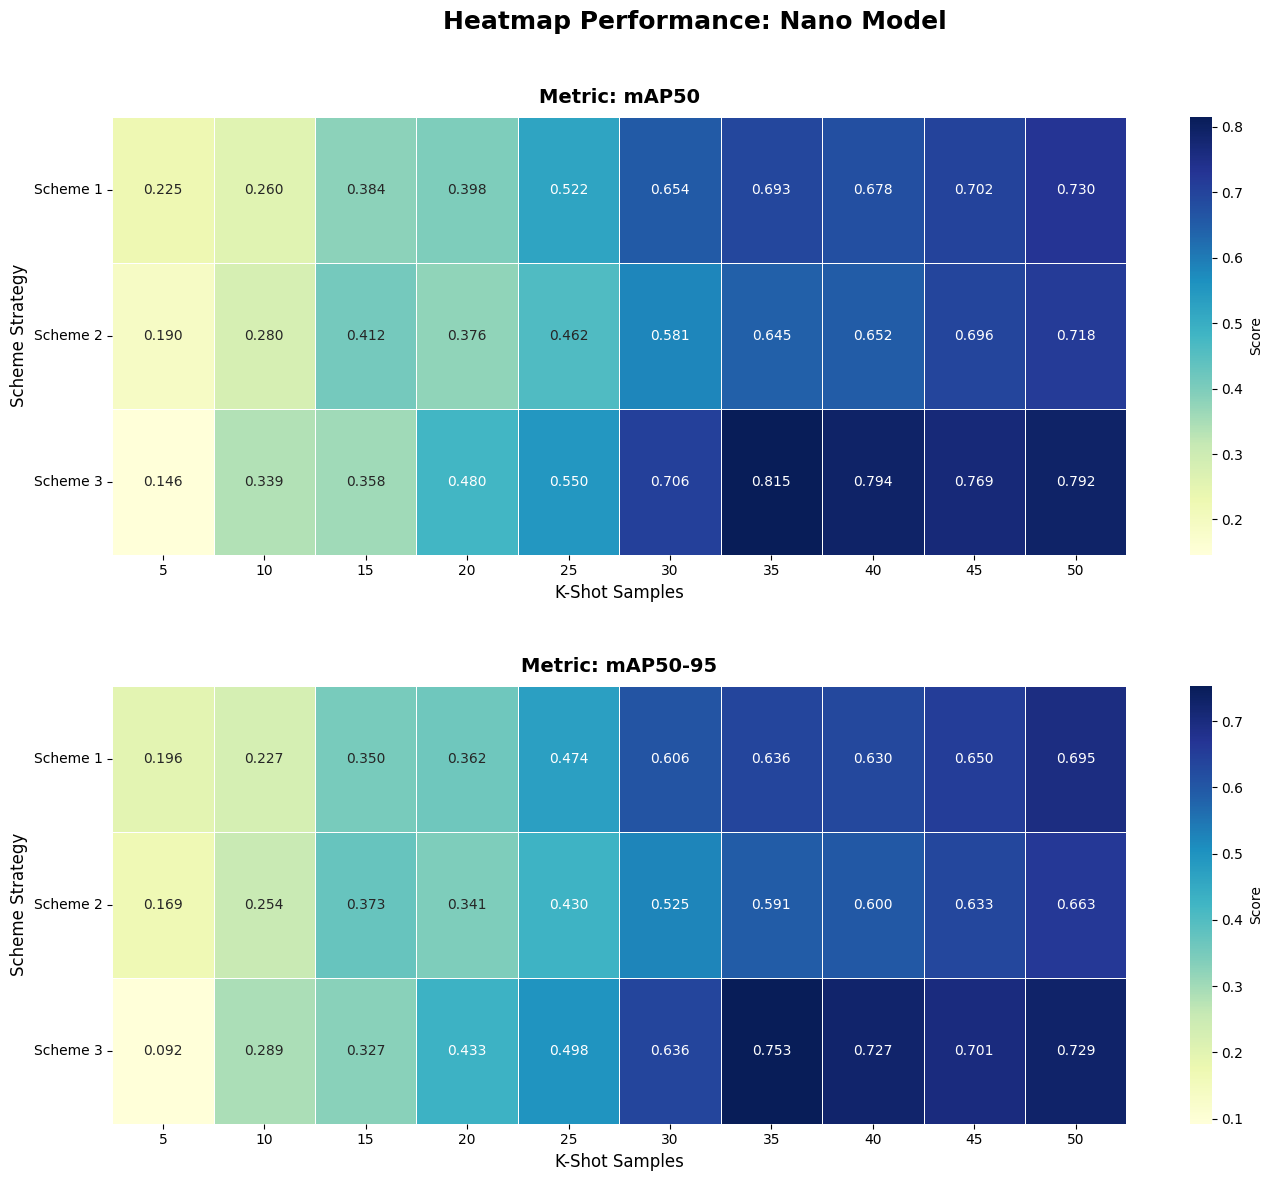

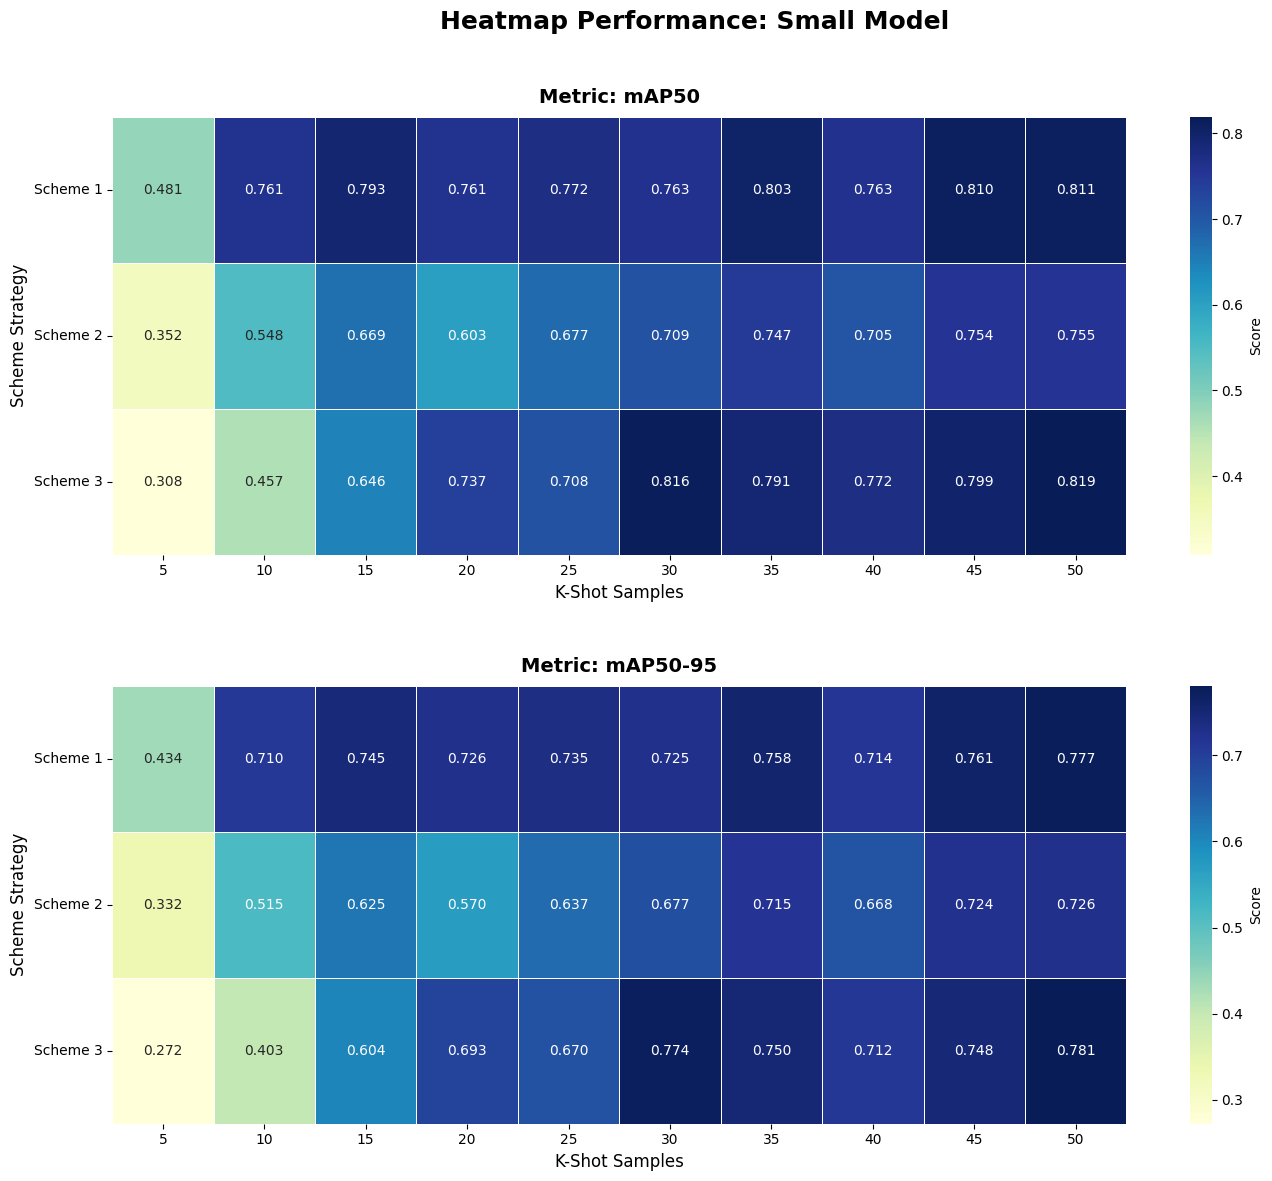

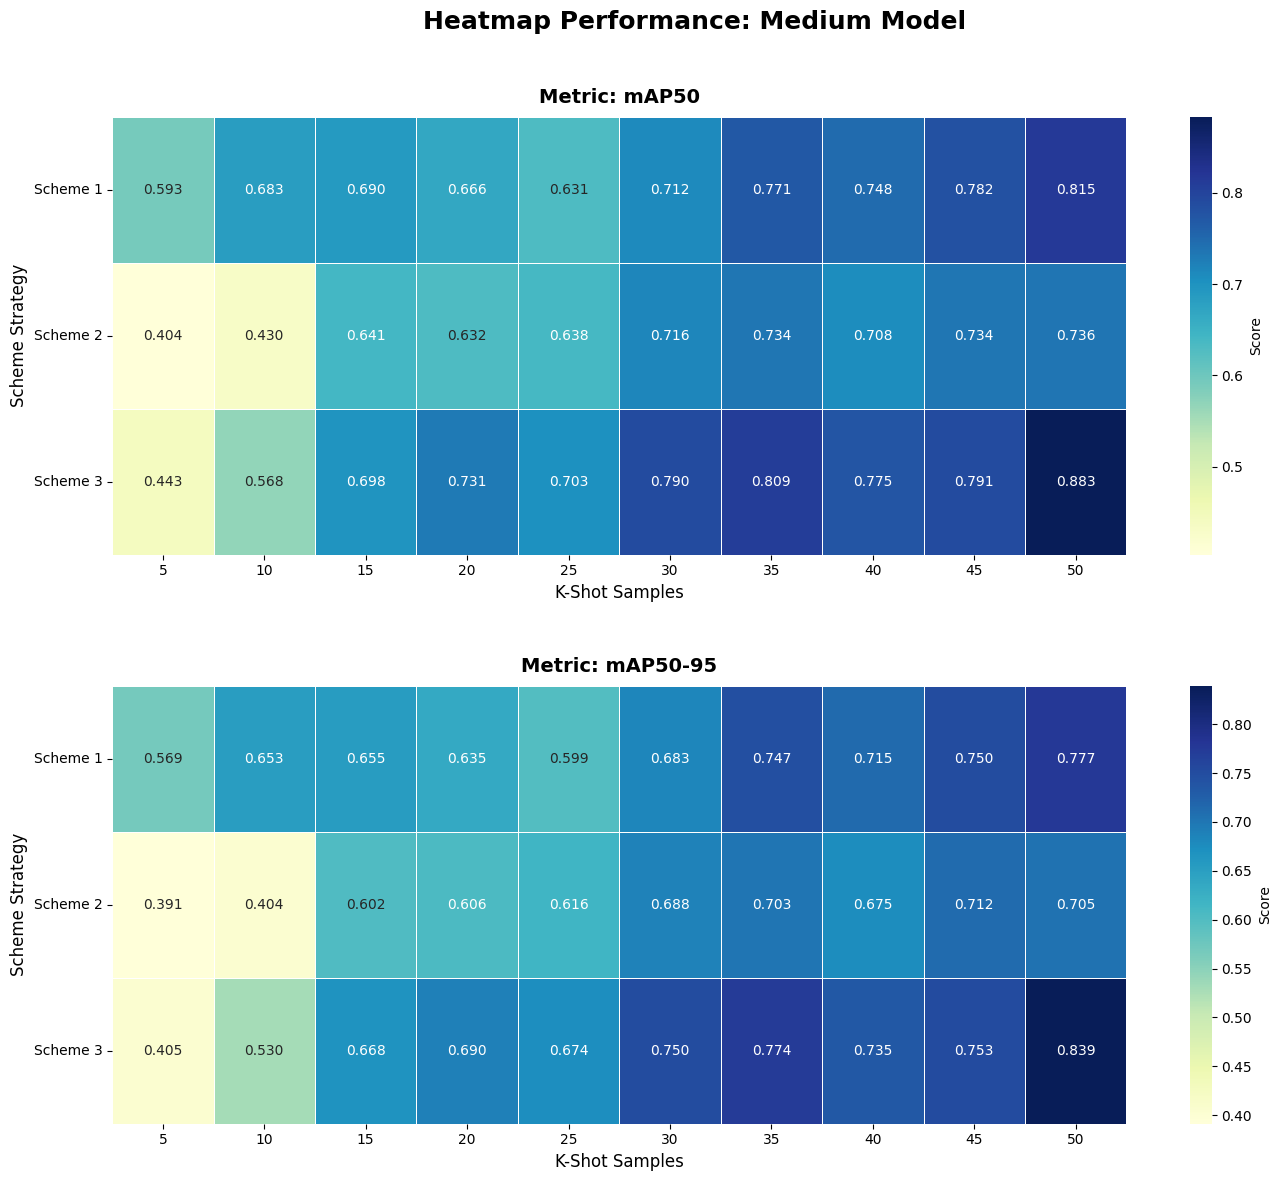

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# --- PATH DATA ---
PATH_SCHEME_1 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"
PATH_SCHEME_2 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-2"
PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# --- KONFIGURASI LABEL ---
SCHEME_CONFIG = {
    'S1': {'path': PATH_SCHEME_1, 'label': 'Scheme 1'},
    'S2': {'path': PATH_SCHEME_2, 'label': 'Scheme 2'},
    'S3': {'path': PATH_SCHEME_3, 'label': 'Scheme 3'}
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_code):
    data = []
    for k in K_VALUES:
        for size in SIZES:
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                    if df.empty: continue
                    
                    last_row = df.iloc[-1]
                    data.append({
                        'Scheme': scheme_code,
                        'Scheme_Label': SCHEME_CONFIG[scheme_code]['label'],
                        'K': k,
                        'Size': size,
                        'mAP50': last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0)),
                        'mAP50-95': last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))
                    })
                except Exception as e:
                    print(f"Error reading {csv_path}: {e}")
    return pd.DataFrame(data)

# --- 3. FUNGSI EXPORT KE CSV ---
def save_aggregated_csv(all_data_df, filename="summary_results.csv"):
    if not all_data_df.empty:
        all_data_df = all_data_df.sort_values(by=['Size', 'Scheme', 'K'])
        all_data_df.to_csv(filename, index=False)
        print(f"\n[SUCCESS] Tabel data berhasil disimpan ke: {filename}")
    else:
        print("\n[WARNING] Tidak ada data untuk disimpan.")

# --- 4. FUNGSI PLOTTING HEATMAP (MODIFIKASI: ATAS-BAWAH) ---
def plot_heatmap_comparison(df):
    if df.empty:
        print("Data Frame kosong, tidak bisa plot.")
        return

    metrics = ['mAP50', 'mAP50-95']
    
    # Loop per Size (Nano, Small, Medium)
    for size in SIZES:
        subset_size = df[df['Size'] == size]
        if subset_size.empty: continue

        # --- MODIFIKASI DISINI ---
        # nrows=2, ncols=1 (Atas Bawah)
        # figsize=(14, 12) -> Lebar 14, Tinggi 12 (Agar proporsional vertikal)
        fig, axes = plt.subplots(2, 1, figsize=(14, 12)) 
        
        fig.suptitle(f"Heatmap Performance: {size.capitalize()} Model", fontsize=18, fontweight='bold', y=0.98)

        for idx, metric in enumerate(metrics):
            ax = axes[idx] # idx 0 = Atas, idx 1 = Bawah
            
            # Pivot Data
            pivot_table = subset_size.pivot(index='Scheme_Label', columns='K', values=metric)
            
            # Urutkan index S1, S2, S3
            ordered_index = [SCHEME_CONFIG[k]['label'] for k in ['S1', 'S2', 'S3'] if SCHEME_CONFIG[k]['label'] in pivot_table.index]
            pivot_table = pivot_table.reindex(ordered_index)

            # Buat Heatmap
            sns.heatmap(pivot_table, 
                        annot=True,         
                        fmt=".3f",          
                        cmap="YlGnBu",      
                        linewidths=.5,      
                        cbar_kws={'label': 'Score'},
                        annot_kws={"size": 10}, # Ukuran font angka
                        ax=ax)

            ax.set_title(f"Metric: {metric}", fontsize=14, fontweight='bold', pad=10)
            ax.set_ylabel("Scheme Strategy", fontsize=12)
            
            # Label X hanya perlu dipertegas di plot paling bawah (opsional, tapi saya pasang di keduanya agar jelas)
            ax.set_xlabel("K-Shot Samples", fontsize=12)
            
            # Putar label Y agar horizontal
            plt.setp(ax.get_yticklabels(), rotation=0)

        # Atur jarak antar subplot agar judul tidak bertabrakan
        plt.tight_layout(rect=[0, 0.0, 1, 0.96])
        
        # Tambahan jarak vertikal antar subplot (h_pad)
        fig.subplots_adjust(hspace=0.3) 
        plt.savefig(f"graph_output/heatmap_comparison_{size}.png", dpi=300)
        plt.show()

# --- 5. EKSEKUSI UTAMA ---
if __name__ == "__main__":
    frames = []
    for code, info in SCHEME_CONFIG.items():
        print(f"Loading data for {code}...")
        df_scheme = load_metrics_from_csv(info['path'], code)
        frames.append(df_scheme)
    
    if frames:
        master_df = pd.concat(frames, ignore_index=True)
        save_aggregated_csv(master_df)
        plot_heatmap_comparison(master_df)
    else:
        print("Semua path data kosong atau tidak ditemukan.")

Mencari performa terbaik (Peak mAP) dari folder Validation Scheme 1B...
  > Nano: Best at K=45 (mAP50-95: 0.7163)
  > Small: Best at K=50 (mAP50-95: 0.8077)
  > Medium: Best at K=30 (mAP50-95: 0.7934)


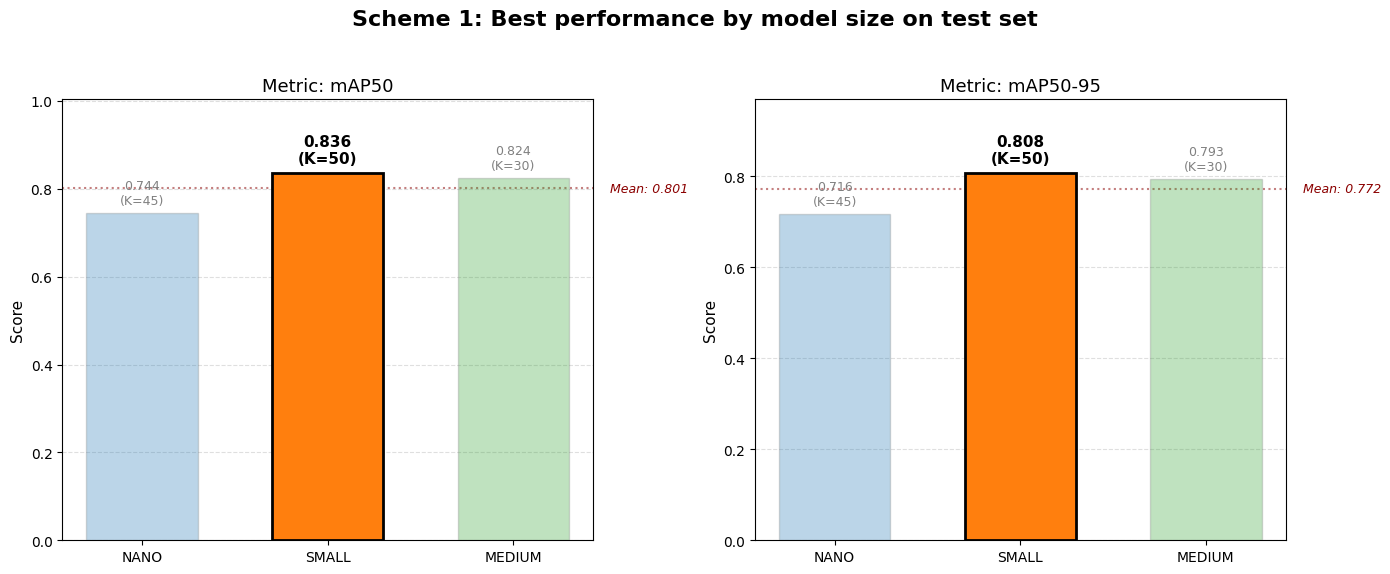

In [19]:
# --- 1. KONFIGURASI ---
# Sesuaikan path ini dengan lokasi root folder results Anda
BASE_PATH_SCHEME_1B = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"

VARIANTS = ["nano", "small", "medium"]
K_VALUES = range(5, 51, 5) # 5, 10, ..., 50

# Palet Warna Standar
COLORS = {
    "nano":   "#1f77b4", # Biru
    "small":  "#ff7f0e", # Oranye
    "medium": "#2ca02c", # Hijau
}

# --- FUNGSI BANTU MEMBACA CSV ---
def load_metrics_from_csv(csv_path):
    """
    Membaca file class_metrics_validation.csv, mencari baris 'all',
    dan mengembalikan (mAP50, mAP50-95).
    """
    try:
        df = pd.read_csv(csv_path)
        # Bersihkan spasi pada nama kolom
        df.columns = [c.strip() for c in df.columns]
        
        # Cari baris dengan class == 'all'
        if 'class' not in df.columns:
             return None, None

        row = df[df['class'] == 'all']
        
        if row.empty:
            return None, None
            
        r = row.iloc[0]
        
        # Ambil nilai mAP dan pastikan float
        m50 = float(r['mAP50'])
        m95 = float(r['mAP50-95'])
        
        return m50, m95

    except Exception as e:
        # print(f"[ERR] Gagal membaca {csv_path}: {e}") # Uncomment untuk debug
        return None, None

# --- 2. PERSIAPAN DATA (MENCARI BEST K UNTUK SETIAP SIZE) ---
results_data = []

print("Mencari performa terbaik (Peak mAP) dari folder Validation Scheme 1B...")

for variant in VARIANTS:
    best_map50 = 0.0
    best_map95 = 0.0
    best_k = -1
    found_any = False
    
    # Loop semua K-shot
    for k in K_VALUES:
        # Konstruksi Path Baru:
        # .../validation/{k}-shot/{variant}/class_metrics_validation.csv
        csv_path = os.path.join(
            BASE_PATH_SCHEME_1B, 
            "validation", 
            f"{k}-shot", 
            variant, 
            "class_metrics_validation.csv"
        )
        
        if os.path.exists(csv_path):
            curr_map50, curr_map95 = load_metrics_from_csv(csv_path)
            
            if curr_map50 is not None and curr_map95 is not None:
                # Cek rekor baru (prioritas mAP50-95)
                if curr_map95 > best_map95:
                    best_map95 = curr_map95
                    best_map50 = curr_map50
                    best_k = k
                found_any = True
    
    # Simpan data terbaik untuk variant ini
    row_data = {"variant": variant}
    if found_any:
        row_data["mAP50"] = best_map50
        row_data["mAP50-95"] = best_map95
        row_data["best_k"] = best_k
        print(f"  > {variant.capitalize()}: Best at K={best_k} (mAP50-95: {best_map95:.4f})")
    else:
        print(f"  [SKIP] Data tidak ditemukan untuk {variant}")
        row_data["mAP50"] = np.nan
        row_data["mAP50-95"] = np.nan
        row_data["best_k"] = "N/A"
        
    results_data.append(row_data)

df = pd.DataFrame(results_data)

# --- 3. VISUALISASI ---
if not df.empty and not df['mAP50'].isnull().all():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Scheme 1: Best performance by model size on test set", fontsize=16, fontweight='bold')

    metrics = ["mAP50", "mAP50-95"]
    bar_w = 0.6 

    for ax, metric in zip(axes, metrics):
        # Cari nilai maksimum untuk highlight
        max_val = df[metric].max()
        
        # Loop manual agar kontrol style lebih mudah per bar
        for i, row in df.iterrows():
            variant = row['variant']
            val = row[metric]
            k_note = row['best_k']
            
            if pd.isna(val): continue

            # Logic: Winner takes all highlighting
            is_best = np.isclose(val, max_val)
            
            # Style Definition
            if is_best:
                alpha = 1.0
                linewidth = 2.0
                edgecolor = 'black'
                zorder = 5
            else:
                alpha = 0.3 # Pudar
                linewidth = 1.0
                edgecolor = 'gray'
                zorder = 3

            # Plot Bar
            bar = ax.bar(
                variant.upper(), 
                val, 
                color=COLORS.get(variant, "gray"),
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
                width=bar_w,
                zorder=zorder
            )
            
            # Annotasi Text
            display_text = f'{val:.3f}\n(K={k_note})'
            
            ax.text(
                bar[0].get_x() + bar[0].get_width()/2., 
                val + 0.015, 
                display_text,
                ha='center', 
                va='bottom', 
                fontsize=11 if is_best else 9,
                fontweight='bold' if is_best else 'normal',
                color='black' if is_best else 'gray'
            )

        # Estetika Grafik
        ax.set_title(f"Metric: {metric}", fontsize=13)
        ax.set_ylabel("Score", fontsize=11)
        
        if not pd.isna(max_val):
            ax.set_ylim(0, max_val * 1.2)
        
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

        # Garis Rata-rata
        mean_val = df[metric].mean()
        ax.axhline(mean_val, color='darkred', linestyle=':', alpha=0.5, zorder=1)
        ax.text(len(VARIANTS)-0.5, mean_val, f' Mean: {mean_val:.3f}', 
                va='center', fontsize=9, color='darkred', style='italic')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("graph_output/scheme_1B_best_model_performance.png", dpi=300)
    plt.show()
else:
    print("Tidak ada data yang valid untuk ditampilkan.")

Grafik gabungan berhasil disimpan di: results/plots/combined_model_comparison.png


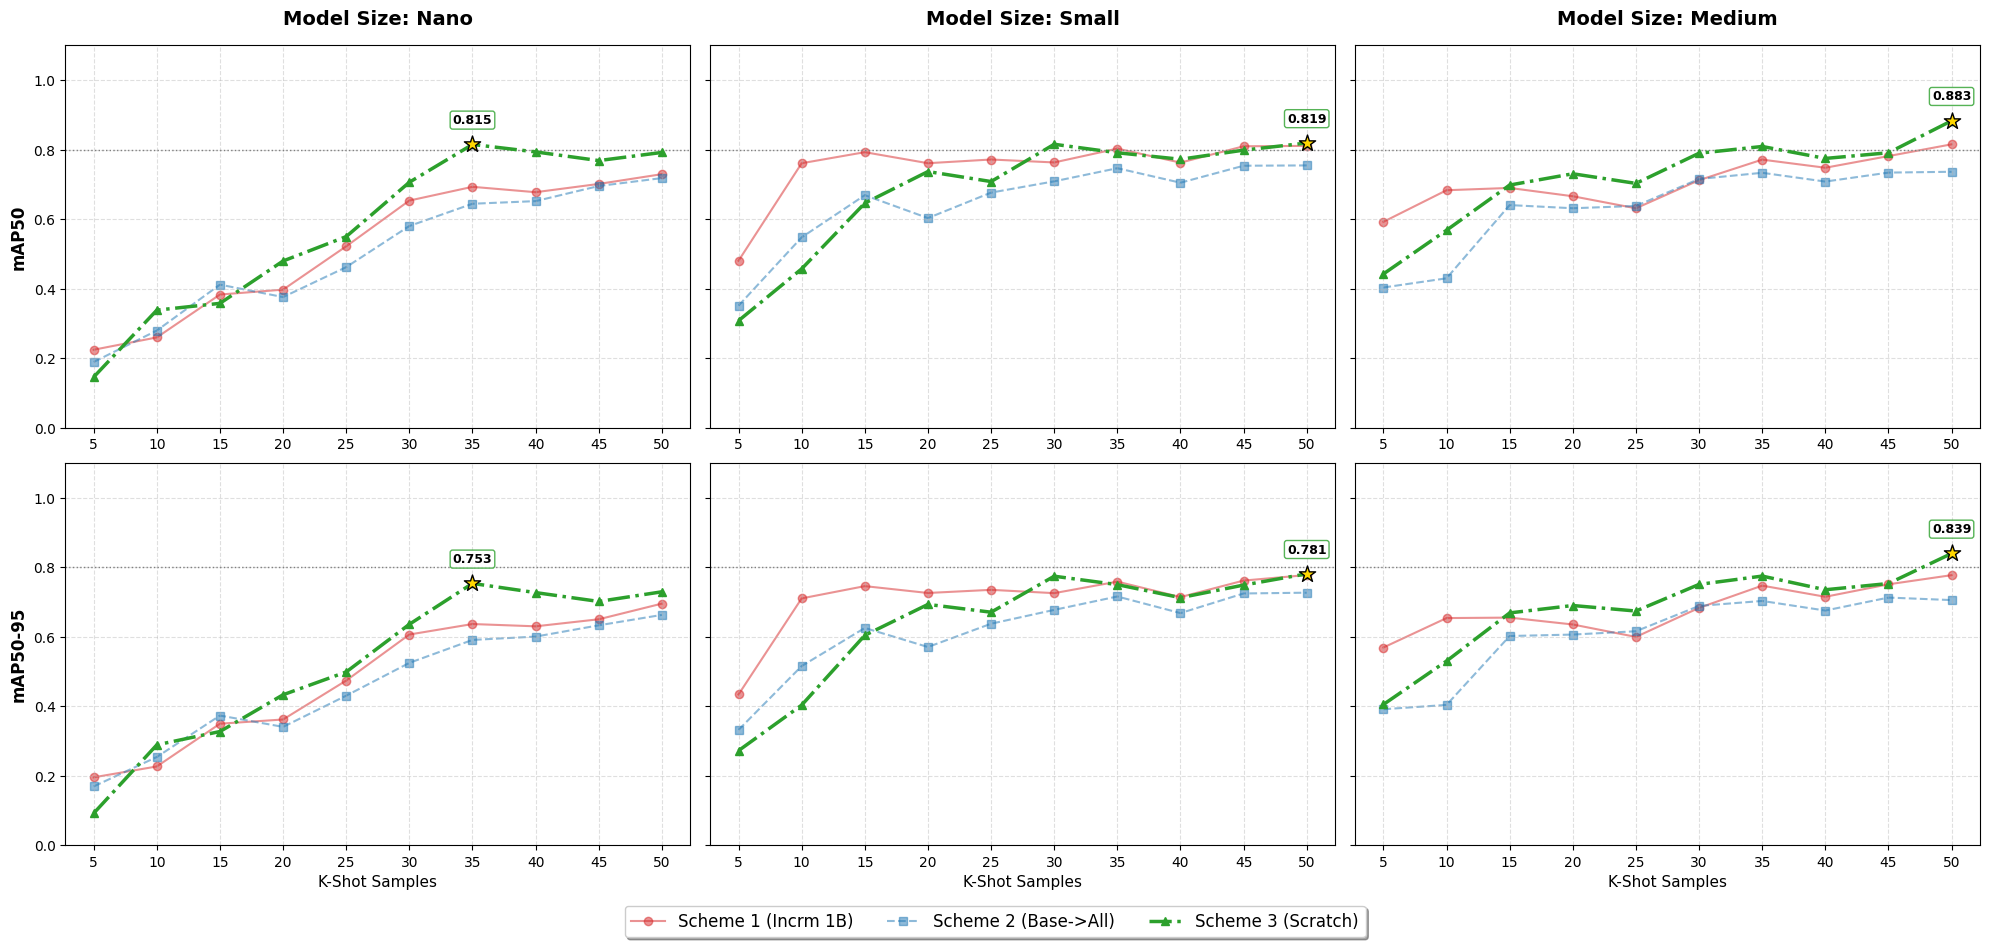

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# --- PATH DATA ---
PATH_SCHEME_1 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"
PATH_SCHEME_2 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-2"
PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# --- KONFIGURASI TAMPILAN ---
SCHEME_CONFIG = {
    'S1': {'path': PATH_SCHEME_1, 'label': 'Scheme 1 (Incrm 1B)', 'color': '#d62728', 'marker': 'o', 'linestyle': '-'},
    'S2': {'path': PATH_SCHEME_2, 'label': 'Scheme 2 (Base->All)', 'color': '#1f77b4', 'marker': 's', 'linestyle': '--'},
    'S3': {'path': PATH_SCHEME_3, 'label': 'Scheme 3 (Scratch)', 'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'}
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_code):
    data = []
    for k in K_VALUES:
        for size in SIZES:
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                    if df.empty: continue
                    last_row = df.iloc[-1]
                    data.append({
                        'Scheme': scheme_code,
                        'K': k,
                        'Size': size,
                        'mAP50': last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0)),
                        'mAP50-95': last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))
                    })
                except: pass
    return pd.DataFrame(data)

# --- 3. FUNGSI PLOTTING GABUNGAN (ALL IN ONE) ---
def plot_combined_grid(data_dict):
    # Setup Figure: 2 Baris (Metrics) x 3 Kolom (Sizes)
    # ShareY=True agar perbandingan tinggi diagram antar model (Nano vs Medium) terlihat jelas
    fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)
    
    # Judul Besar (Opsional, kadang di jurnal tidak perlu judul besar di gambar karena ada caption)
    # fig.suptitle("Comparative Analysis: YOLO v12 Few-Shot Learning Schemes", fontsize=18, fontweight='bold', y=0.98)

    metrics = [('mAP50', 'mAP50'), ('mAP50-95', 'mAP50-95')]
    
    # --- LOOP UTAMA ---
    for row_idx, (metric_col, metric_title) in enumerate(metrics):
        for col_idx, size in enumerate(SIZES):
            
            ax = axes[row_idx, col_idx]
            
            # --- LOGIKA CARI PEMENANG PER SUBPLOT ---
            best_scheme = None
            max_peak_val = -1
            plot_data = [] 
            
            # Filter Data
            for scheme_code in ['S1', 'S2', 'S3']:
                df = data_dict[scheme_code]
                if df.empty: continue
                subset = df[df['Size'] == size].sort_values('K')
                if subset.empty: continue
                
                peak = subset[metric_col].max()
                if peak > max_peak_val:
                    max_peak_val = peak
                    best_scheme = scheme_code
                
                plot_data.append({'code': scheme_code, 'data': subset})
            
            # --- PLOTTING GARIS ---
            for item in plot_data:
                code = item['code']
                subset = item['data']
                config = SCHEME_CONFIG[code]
                
                is_winner = (code == best_scheme)
                
                # Visual Style
                alpha = 1.0 if is_winner else 0.5
                linewidth = 2.5 if is_winner else 1.5
                zorder = 10 if is_winner else 1
                
                # Label hanya kita simpan, tapi tidak dimasukkan ke ax.legend() di setiap subplot
                # agar tidak berantakan. Kita akan buat 1 Legend global nanti.
                label = config['label']

                ax.plot(subset['K'], subset[metric_col], 
                        color=config['color'], 
                        linestyle=config['linestyle'], 
                        linewidth=linewidth, 
                        marker=config['marker'], 
                        markersize=6, 
                        alpha=alpha, 
                        zorder=zorder,
                        label=label) # Label tetap dipasang untuk diambil handles-nya nanti
                
                # Highlight Pemenang (Bintang & Angka)
                if is_winner:
                    max_k = subset.loc[subset[metric_col].idxmax(), 'K']
                    max_val = subset[metric_col].max()
                    ax.scatter(max_k, max_val, s=150, color='gold', edgecolors='black', zorder=11, marker='*')
                    
                    # Anotasi Angka (Dikecilkan sedikit agar muat)
                    ax.annotate(f"{max_val:.3f}", (max_k, max_val), 
                                xytext=(0, 15), textcoords='offset points', 
                                ha='center', fontsize=9, fontweight='bold',
                                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=config['color'], alpha=0.8))

            # --- KOSMETIK SUBPLOT ---
            # Judul Kolom (Hanya di baris paling atas)
            if row_idx == 0:
                ax.set_title(f"Model Size: {size.capitalize()}", fontsize=14, fontweight='bold', pad=15)
            
            # Label Y (Hanya di kolom paling kiri)
            if col_idx == 0:
                ax.set_ylabel(metric_title, fontsize=12, fontweight='bold')
            
            # Label X (Hanya di baris paling bawah)
            if row_idx == 1:
                ax.set_xlabel("K-Shot Samples", fontsize=11)
            
            ax.axhline(y=THRESHOLD_VAL, color='gray', linestyle=':', linewidth=1)
            ax.set_xticks(K_VALUES)
            ax.set_ylim(0, 1.1)
            ax.grid(True, linestyle='--', alpha=0.4)

    # --- GLOBAL LEGEND ---
    # Ambil handles dan labels dari subplot terakhir
    lines, labels = axes[0, 0].get_legend_handles_labels()
    # Letakkan legend di bawah tengah
    fig.legend(lines, labels, loc='lower center', ncol=3, fontsize=12, 
               frameon=True, shadow=True, bbox_to_anchor=(0.5, 0.02))

    # Atur layout agar ada ruang untuk legend di bawah
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, top=0.92) # Bottom diberi ruang untuk legend
    
    # Simpan
    os.makedirs("results/plots", exist_ok=True)
    save_path = "results/plots/combined_model_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Grafik gabungan berhasil disimpan di: {save_path}")
    plt.show()

# --- 4. EKSEKUSI ---
data_store = {}
for code, info in SCHEME_CONFIG.items():
    data_store[code] = load_metrics_from_csv(info['path'], code)

plot_combined_grid(data_store)

Loading data for S1...
Loading data for S2...
Loading data for S3...
[SUCCESS] Grafik Heatmap Gabungan disimpan di: results/plots/combined_heatmap_comparison.png


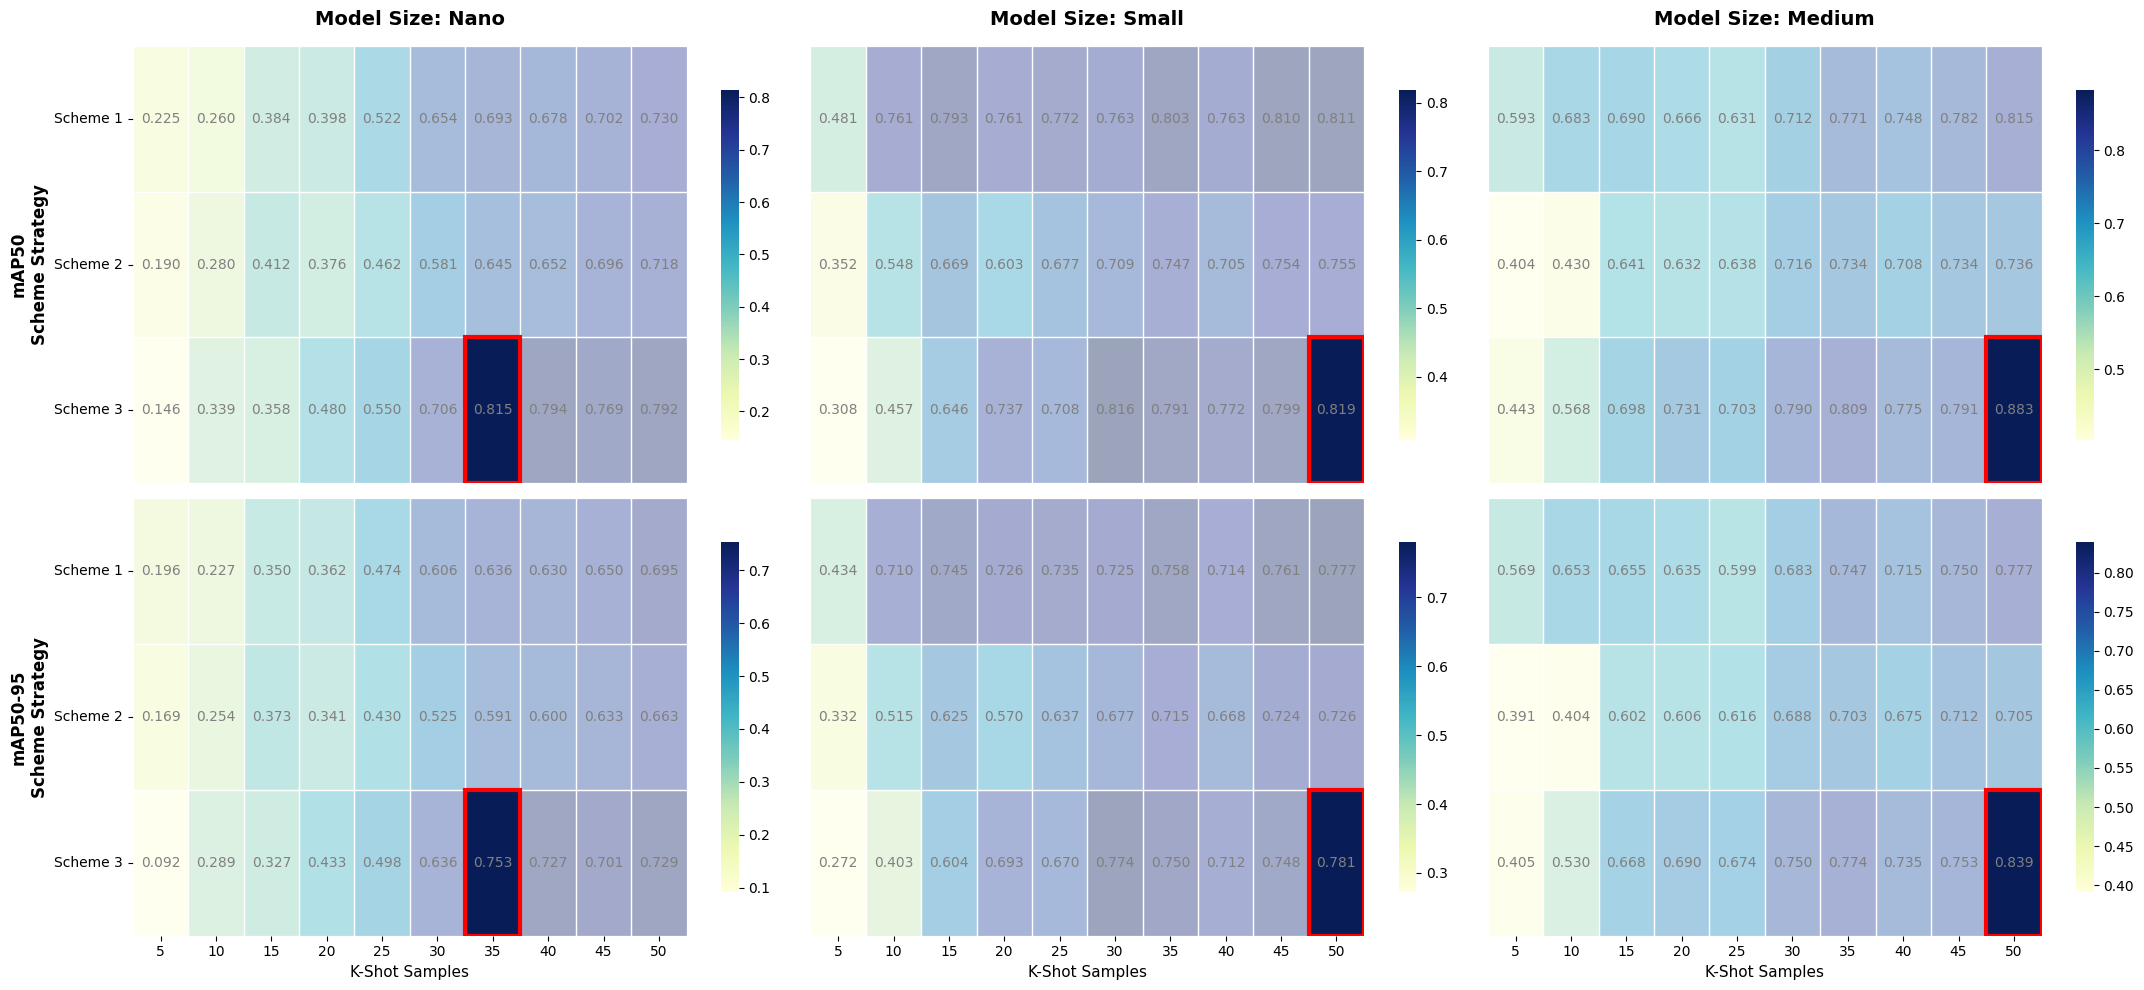

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os
import numpy as np

# --- 1. KONFIGURASI GLOBAL ---
SIZES = ['nano', 'small', 'medium']
K_VALUES = range(5, 51, 5) 
THRESHOLD_VAL = 0.8 

# --- PATH DATA ---
PATH_SCHEME_1 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-1B"
PATH_SCHEME_2 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-2"
PATH_SCHEME_3 = "runs/detect/results/yolo_v12/object_detection_novel_class_scheme-3"

# --- KONFIGURASI LABEL ---
SCHEME_CONFIG = {
    'S1': {'path': PATH_SCHEME_1, 'label': 'Scheme 1'},
    'S2': {'path': PATH_SCHEME_2, 'label': 'Scheme 2'},
    'S3': {'path': PATH_SCHEME_3, 'label': 'Scheme 3'}
}

# --- 2. FUNGSI LOAD DATA ---
def load_metrics_from_csv(base_project_path, scheme_code):
    data = []
    for k in K_VALUES:
        for size in SIZES:
            csv_path = os.path.join(base_project_path, "training", f"{k}-shot", size, "results.csv")
            if os.path.exists(csv_path):
                try:
                    df = pd.read_csv(csv_path)
                    df.columns = [c.strip() for c in df.columns]
                    if df.empty: continue
                    last_row = df.iloc[-1]
                    data.append({
                        'Scheme': scheme_code,
                        'Scheme_Label': SCHEME_CONFIG[scheme_code]['label'],
                        'K': k,
                        'Size': size,
                        'mAP50': last_row.get('metrics/mAP50(B)', last_row.get('val mAP50', 0)),
                        'mAP50-95': last_row.get('metrics/mAP50-95(B)', last_row.get('val mAP50-95', 0))
                    })
                except Exception as e:
                    print(f"Error reading {csv_path}: {e}")
    return pd.DataFrame(data)

# --- 3. HELPER: SPOTLIGHT EFFECT ---
def apply_spotlight_effect(ax, pivot_data):
    """
    Memberikan efek highlight pada nilai tertinggi (Global Max di subplot tersebut).
    - Pemenang: Border Merah Tebal, Teks Hitam Tebal.
    - Kalah: Ditutup layer putih transparan (faded).
    """
    max_val = pivot_data.max().max()
    rows, cols = pivot_data.shape
    
    # 1. Loop Kotak (Rectangles)
    for y in range(rows):
        for x in range(cols):
            val = pivot_data.iloc[y, x]
            # Koordinat (x, y)
            if val < max_val:
                # Fading effect untuk yang kalah (Putih transparan)
                rect = patches.Rectangle((x, y), 1, 1, fill=True, color='white', alpha=0.6, zorder=2)
                ax.add_patch(rect)
            else:
                # Highlight effect untuk pemenang (Border Merah)
                rect = patches.Rectangle((x, y), 1, 1, fill=False, edgecolor='#FF0000', linewidth=3, zorder=5)
                ax.add_patch(rect)
                
    # 2. Loop Teks (Annotations)
    for text in ax.texts:
        try:
            val_text = float(text.get_text())
            if val_text == max_val:
                text.set_weight('bold')
                text.set_color('black')
                text.set_size(11)
                text.set_zorder(10)
            else:
                text.set_color('gray') # Teks yang kalah jadi abu-abu
        except: pass

# --- 4. FUNGSI PLOTTING HEATMAP GABUNGAN (2x3 GRID) ---
def plot_combined_heatmap_grid(df):
    if df.empty: return

    metrics = ['mAP50', 'mAP50-95']
    
    # Setup Figure: 2 Baris (Metrics) x 3 Kolom (Sizes)
    # figsize=(22, 10) -> Cukup lebar untuk menampung 3 heatmap berdampingan
    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # Loop Utama
    for row_idx, metric in enumerate(metrics):
        for col_idx, size in enumerate(SIZES):
            
            ax = axes[row_idx, col_idx]
            
            # Filter Data
            subset = df[df['Size'] == size]
            if subset.empty: 
                ax.axis('off')
                continue

            # Pivot Data
            pivot_table = subset.pivot(index='Scheme_Label', columns='K', values=metric)
            
            # Reorder Index (S1 -> S2 -> S3)
            ordered_index = [SCHEME_CONFIG[k]['label'] for k in ['S1', 'S2', 'S3'] if SCHEME_CONFIG[k]['label'] in pivot_table.index]
            pivot_table = pivot_table.reindex(ordered_index)

            # Draw Heatmap
            sns.heatmap(pivot_table, 
                        annot=True, 
                        fmt=".3f", 
                        cmap="YlGnBu", 
                        linewidths=.5, 
                        cbar=True, # Tampilkan colorbar kecil di samping tiap plot
                        cbar_kws={'shrink': 0.8}, # Perkecil ukuran colorbar
                        ax=ax)

            # Apply Spotlight (Highlight Winner)
            apply_spotlight_effect(ax, pivot_table)

            # --- KOSTUMISASI LABEL AGAR RAPI (JURNAL STYLE) ---
            
            # Judul Kolom (Hanya di Baris Teratas)
            if row_idx == 0:
                ax.set_title(f"Model Size: {size.capitalize()}", fontsize=14, fontweight='bold', pad=15)
            else:
                ax.set_title("") # Kosongkan judul di baris kedua
            
            # Label Y (Hanya di Kolom Paling Kiri)
            if col_idx == 0:
                ax.set_ylabel(f"{metric}\nScheme Strategy", fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel("") # Hilangkan label Y di tengah & kanan
                ax.set_yticks([]) # Hilangkan ticks Y juga agar bersih

            # Label X (Hanya di Baris Paling Bawah)
            if row_idx == 1:
                ax.set_xlabel("K-Shot Samples", fontsize=11)
            else:
                ax.set_xlabel("") # Hilangkan label X di baris atas
                ax.set_xticks([]) # Hilangkan ticks X

            # Rotasi label Y agar horizontal (jika ada)
            plt.setp(ax.get_yticklabels(), rotation=0)

    # Layout Adjustment
    plt.tight_layout()
    
    # Simpan
    os.makedirs("results/plots", exist_ok=True)
    save_path = "results/plots/combined_heatmap_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[SUCCESS] Grafik Heatmap Gabungan disimpan di: {save_path}")
    plt.show()

# --- 5. EKSEKUSI UTAMA ---
if __name__ == "__main__":
    frames = []
    for code, info in SCHEME_CONFIG.items():
        print(f"Loading data for {code}...")
        df_scheme = load_metrics_from_csv(info['path'], code)
        frames.append(df_scheme)
    
    if frames:
        master_df = pd.concat(frames, ignore_index=True)
        plot_combined_heatmap_grid(master_df)
    else:
        print("Data kosong.")